# Quantifying the Recall Cost of Reduction
## Dimensionality Reduction and Sensitivity Optimization in Breast Cancer Diagnosis

**Author:** Matthew Dutton  
**Course:** DTSA 5506 - Data Mining Project  
**Institution:** University of Colorado at Boulder  
**Date:** March 2026

---

## Abstract

In medical diagnostics, the high degree of correlation between cell measurements can make machine learning models unstable. While simplifying this data through dimensionality reduction makes models more efficient, it carries a significant risk: increasing False Negatives. This is a critical concern because cancer screening errors are not created equal - a false alarm is manageable, but a missed diagnosis can be fatal.

This study evaluates the impact of Principal Component Analysis (PCA) on Support Vector Machine (SVM) sensitivity using the classic Breast Cancer Wisconsin (Diagnostic) dataset. To quantify this safety-efficiency trade-off, we introduce a new metric: the *Recall Cost of Reduction* ($RCR$).

Through a systematic component sweep and joint hyperparameter optimization via `GridSearchCV`, we demonstrate that aggressive dimensionality reduction does not just maintain diagnostic safety, it improves it. Our findings show:

- **Optimal Performance**: A Grid Search–optimized SVM with $k=3$ components achieves a perfect Recall of 1.0000 ($RCR = -0.050$), eliminating all False Negatives while reducing dimensionality by 90%.
- **Noise Filtering**: Even without hyperparameter tuning, a linear SVM at $k=2$ improves Recall from a baseline of 0.9524 to 0.9762. This suggests that variance-driven compression serves as an effective noise-filtering mechanism, yielding a "Sensitivity Rebate" (negative $RCR$).
- **Robustness**: Results were validated using five-fold stratified cross-validation (CV Baseline Recall = 0.9623).

By codifying the $RCR$, this project establishes a formal framework for high-stakes machine learning that prioritizes patient safety by minimizing missed diagnoses through smarter data simplification.

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Data Loading & Exploration](#2-data)
3. [Exploratory Data Analysis (EDA)](#3-eda)
4. [Data Preprocessing](#4-preprocessing)
5. [Baseline Model](#5-baseline)
6. [PCA Dimensionality Reduction Analysis](#6-pca)
7. [Hyperparameter Optimization](#7-optimization)
8. [Results & Discussion](#8-results)
9. [Conclusions](#9-conclusions)
10. [References](#10-references)

<a id="1-introduction"></a>
## 1. Introduction

In oncology, the cost-function of misclassification is profoundly asymmetric. Missing a malignancy (False Negative) can lead to delayed treatment and increased patient mortality, whereas a false alarm (False Positive) typically results in manageable, albeit stressful, follow-up procedures. Consequently, diagnostic systems must prioritize Recall (Sensitivity) as the primary governing constraint to ensure that all positive cases are captured.

![Confusion Matrix](Confusion%20Matrix.jpg)

However, the pursuit of maximum sensitivity is often complicated by the underlying structure of the clinical data itself. In modern diagnostics, models must process high-dimensional morphological features, yet the extreme multicollinearity between these measurements, such as the size, shape, and texture of cells, paradoxically can make machine learning models unstable and overconfident.

The [Breast Cancer Wisconsin (Diagnostic)](https://www.kaggle.com/datasets/ciml/breast-cancer-wisconsin-data) dataset is the ideal benchmark for studying the inherent tension between data complexity and clinical safety. Because many of the features of the dataset (notably perimeter, radius, and area) are mathematically redundant, they often lead to overfitting. To address this, Principal Component Analysis (PCA) is frequently used to compress the data into an efficient eigenspace. Yet, because PCA prioritizes global variance rather than diagnostic nuances, there is a persistent risk that aggressive compression might discard subtle markers essential for identifying malignant cells.

This project introduces the Recall Cost of Reduction ($RCR$) to quantify the trade-off between dimensionality reduction and diagnostic safety. Unlike standard accuracy metrics, $RCR$ specifically measures the preservation of the "positive" class (malignancy) relative to a full-featured baseline.

Let $Rn$ represent the Recall achieved by a classifier using the full feature set ($n = 30$) and $Rk$ represent the Recall achieved using a reduced set of $k$ principal components. The $RCR$ is defined as:

$\mathcal{RCR}(k) = 1 - \frac{R_k}{R_{n}}$

The value of $RCR$ provides a direct assessment of the "safety price" paid for data simplification, and can be interpreted thusly:

- $RCR > 0$: Indicates a *Sensitivity Tax*. Reducing the data has caused the model to miss malignant cases that were caught by the baseline.
- $RCR = 0$: Indicates *Neutral Reduction*. The data was successfully compressed without any loss in diagnostic sensitivity.
- $RCR < 0$: Indicates a *Sensitivity Rebate*. The reduction process improved the model's ability to identify cancer, by filtering out stochastic noise and redundant features that destabilized the baseline decision boundary.

This framework provides a normalized benchmark for "diagnostic decay." By framing the loss as a ratio relative to the full feature set, we make it possible to quantify the exact percentage of sensitivity that is sacrificed for computational efficiency.

<a id="2-data"></a>
## 2. Data Loading & Setup

### 2.1 Import Libraries

We use the following libraries for this analysis:
- **NumPy & Pandas:** Data manipulation and analysis
- **Matplotlib & Seaborn:** Data visualization
- **Scikit-learn:** Machine learning algorithms and preprocessing

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from scipy.stats import loguniform
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.metrics import (
    recall_score, 
    precision_score, 
    f1_score, 
    confusion_matrix, 
    classification_report
)
from sklearn.model_selection import (
    cross_val_score, 
    train_test_split, 
    StratifiedKFold, 
    GridSearchCV, 
    RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from tqdm.notebook import tqdm

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

In [3]:
# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 2.2 Load the Dataset

The Wisconsin dataset contains features computed from digitized images of fine needle aspirates (FNA) of breast masses. Each feature describes characteristics of cell nuclei present in the image.

In [4]:
# Load the breast cancer dataset
data = load_breast_cancer()

# Display dataset description
print("=" * 70)
print("WISCONSIN BREAST CANCER DATASET")
print("=" * 70)
print(f"\n📊 Dataset Shape: {data.data.shape[0]} samples, {data.data.shape[1]} features")
print(f"🎯 Target Classes: {data.target_names}")
print(f"\n📝 Description:\n{data.DESCR}")

WISCONSIN BREAST CANCER DATASET

📊 Dataset Shape: 569 samples, 30 features
🎯 Target Classes: ['malignant' 'benign']

📝 Description:
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each imag

### 2.3 Extract Features and Target

In [5]:
# Extract features and target
X = data.data
y = data.target
feature_names = data.feature_names

# Create a DataFrame for easier manipulation
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"\n🔬 Feature Names ({len(feature_names)} features):")
for i, name in enumerate(feature_names, 1):
    print(f"  {i:2d}. {name}")

Feature matrix shape: (569, 30)
Target vector shape: (569,)

🔬 Feature Names (30 features):
   1. mean radius
   2. mean texture
   3. mean perimeter
   4. mean area
   5. mean smoothness
   6. mean compactness
   7. mean concavity
   8. mean concave points
   9. mean symmetry
  10. mean fractal dimension
  11. radius error
  12. texture error
  13. perimeter error
  14. area error
  15. smoothness error
  16. compactness error
  17. concavity error
  18. concave points error
  19. symmetry error
  20. fractal dimension error
  21. worst radius
  22. worst texture
  23. worst perimeter
  24. worst area
  25. worst smoothness
  26. worst compactness
  27. worst concavity
  28. worst concave points
  29. worst symmetry
  30. worst fractal dimension


<a id="3-eda"></a>
## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

A critical observation from the summary statistics below is the **vastly different scales** among features. For example:

- `area_mean` has values around **654** (mean)
- `smoothness_mean` has values around **0.096** (mean)

This represents a **~6,800× scale difference**. Such disparities are problematic for PCA because:

1. **PCA maximizes variance** — features with larger magnitudes will dominate the principal components simply due to their scale, not their actual importance
2. **Distance-based algorithms** (like the SVM we use for classification) are also sensitive to feature scales

This observation motivates our use of `StandardScaler` in Section 4, which transforms all features to have zero mean and unit variance before applying PCA.

In [6]:
# Basic statistics
print("📊 DATASET SUMMARY STATISTICS")
print("=" * 70)
display(df.describe().T.style.background_gradient(cmap='Blues'))

# Check for missing values
print(f"\n🔍 Missing Values: {df.isnull().sum().sum()}")
print(f"📐 Data Types:\n{df.dtypes.value_counts()}")

📊 DATASET SUMMARY STATISTICS


,count,mean,std,min,25%,50%,75%,max
mean radius,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
mean texture,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
mean perimeter,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
mean area,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
mean smoothness,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
mean compactness,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
mean concavity,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
mean concave points,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
mean symmetry,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000
mean fractal dimension,569.000000,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.097440



🔍 Missing Values: 0
📐 Data Types:
float64    30
int32       1
object      1
Name: count, dtype: int64


### 3.2 Class Distribution

Understanding class imbalance is critical for medical diagnosis tasks, as it affects model training and evaluation metrics.

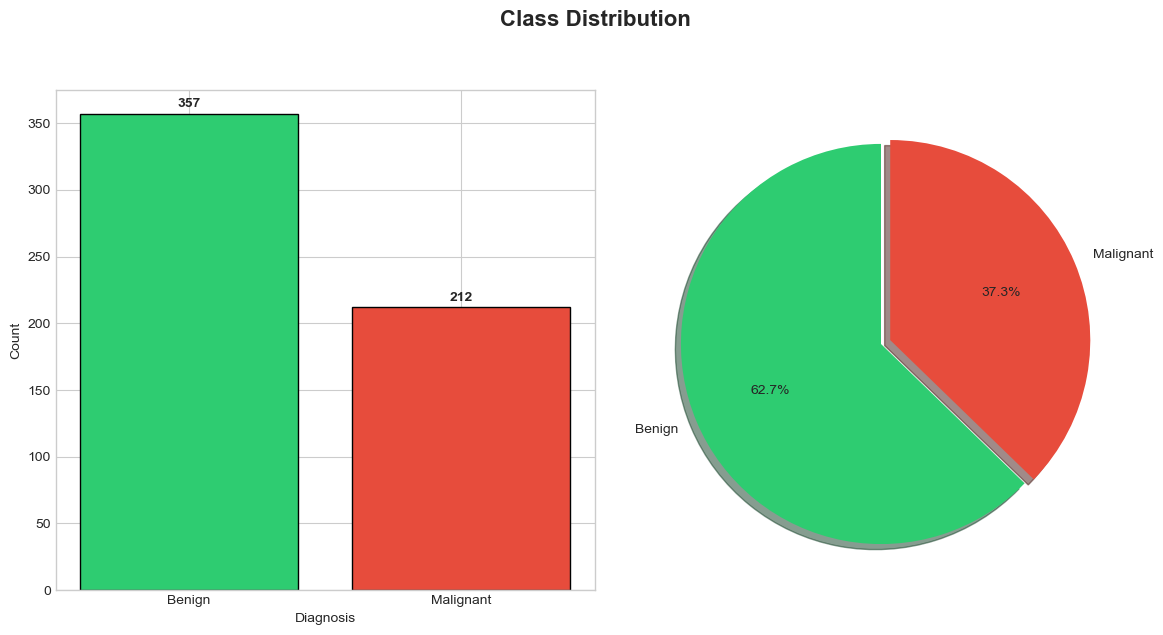

In [7]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
color_dict = {'Benign': '#2ecc71', 'Malignant': '#e74c3c'}
class_counts = df['diagnosis'].value_counts()
bar_colors = [color_dict[cls] for cls in class_counts.index]
axes[0].bar(class_counts.index, class_counts.values, color=bar_colors, edgecolor='black')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

pie_colors = [color_dict[cls] for cls in class_counts.index]
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=pie_colors, explode=(0.05, 0), shadow=True, startangle=90)

fig.suptitle('Class Distribution', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 3.3 Feature Distributions

Analyzing feature distributions helps identify potential outliers and understand the data characteristics.

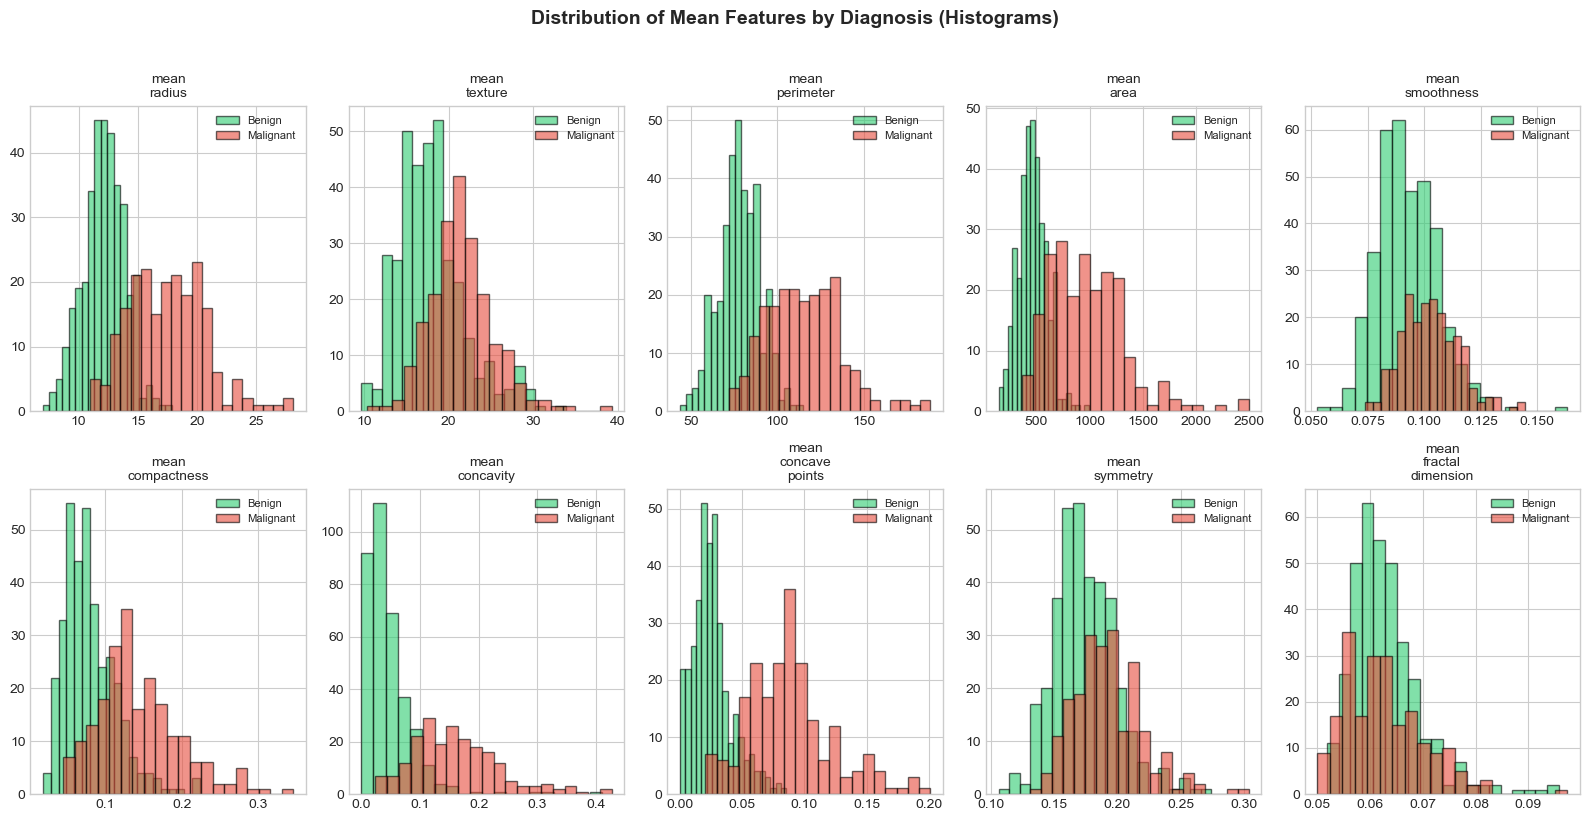

In [8]:
# Feature distributions - select key features (mean values)
mean_features = [col for col in feature_names if 'mean' in col]

# Histograms
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    ax = axes[i]
    for diagnosis, color in [('Benign', '#2ecc71'), ('Malignant', '#e74c3c')]:
        subset = df[df['diagnosis'] == diagnosis][feature]
        ax.hist(subset, bins=20, alpha=0.6, label=diagnosis, color=color, edgecolor='black')
    ax.set_title(feature.replace(' ', '\n'), fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Mean Features by Diagnosis (Histograms)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

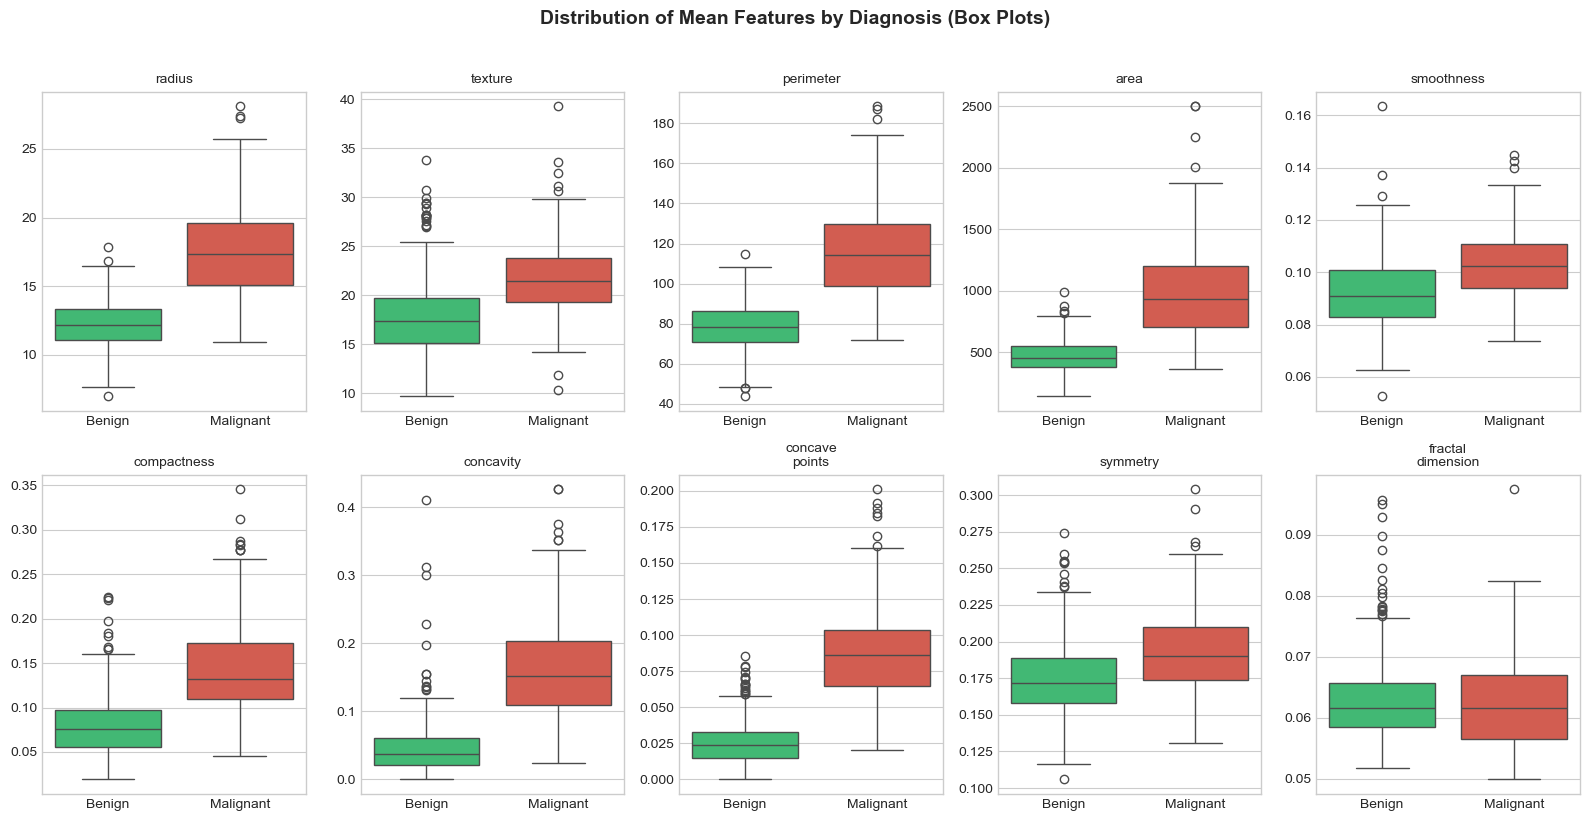

In [9]:
# Box plots
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

colors = {'Benign': '#2ecc71', 'Malignant': '#e74c3c'}
for i, feature in enumerate(mean_features):
    ax = axes[i]
    sns.boxplot(data=df, x='diagnosis', y=feature, hue='diagnosis', ax=ax, 
                palette=colors, order=['Benign', 'Malignant'], legend=False)
    ax.set_title(feature.replace('mean ', '').replace(' ', '\n'), fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.suptitle('Distribution of Mean Features by Diagnosis (Box Plots)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.4 Correlation Analysis

Understanding feature correlations is crucial for PCA, as highly correlated features indicate redundancy that PCA can exploit.

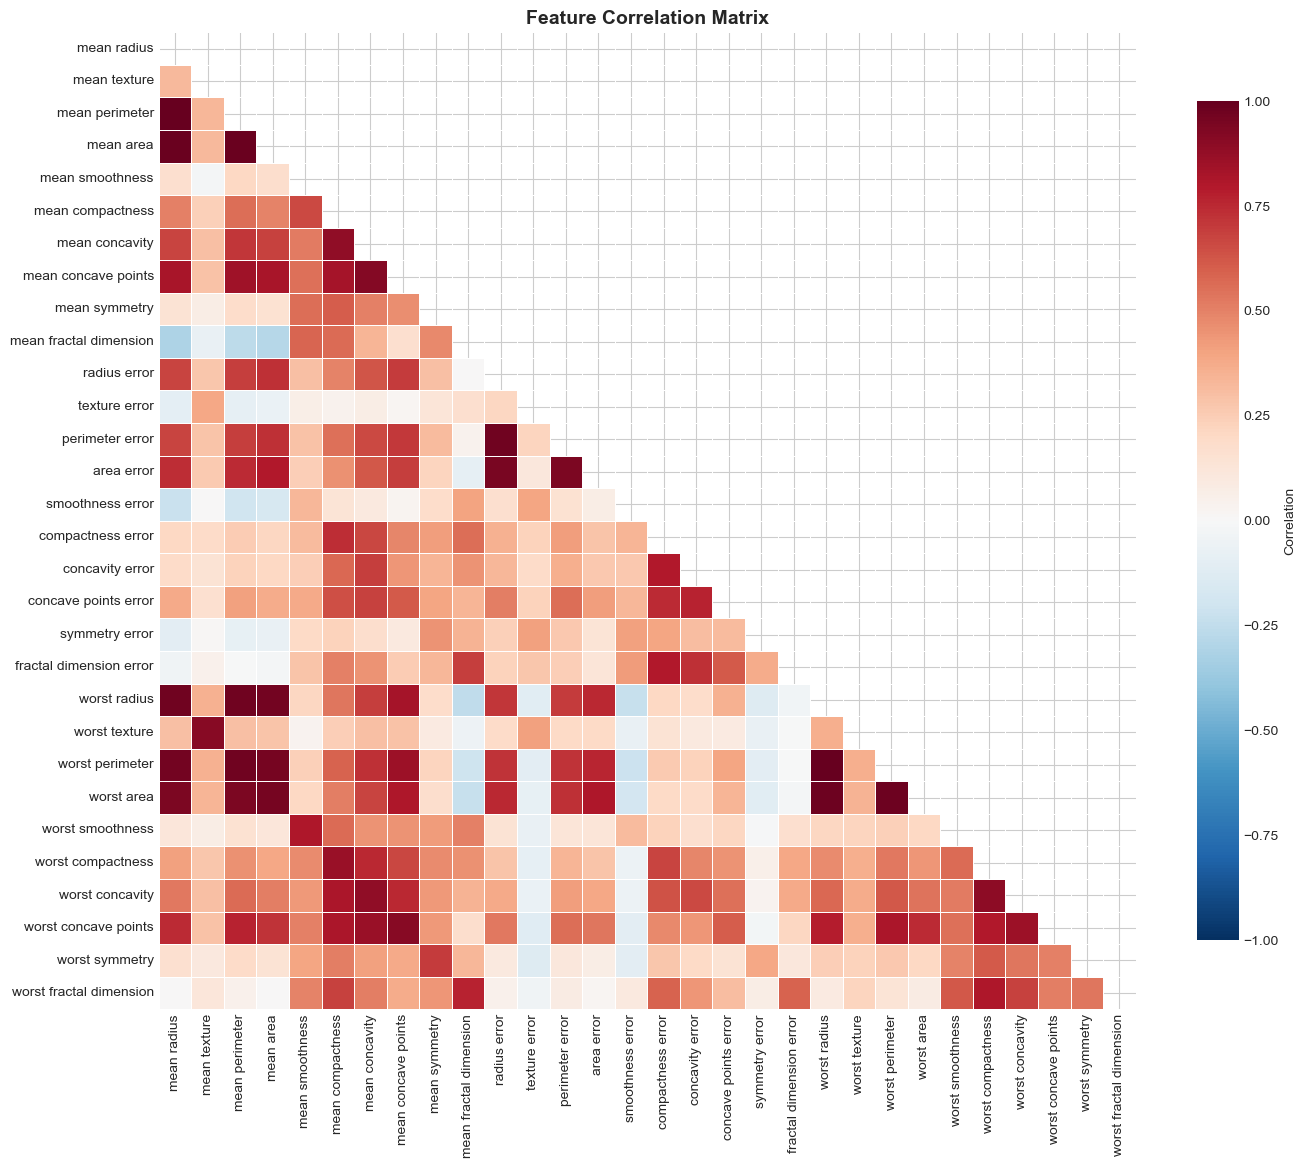

,Feature 1,Feature 2,Correlation
0,mean radius,mean perimeter,0.9979
1,worst radius,worst perimeter,0.9937
2,mean radius,mean area,0.9874
3,mean perimeter,mean area,0.9865
4,worst radius,worst area,0.9840
5,worst perimeter,worst area,0.9776
6,radius error,perimeter error,0.9728
7,mean perimeter,worst perimeter,0.9704
8,mean radius,worst radius,0.9695
9,mean perimeter,worst radius,0.9695


In [10]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))

# Compute correlation matrix for features only
corr_matrix = df[feature_names].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated feature pairs
highly_correlated_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            highly_correlated_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

high_corr_df = (
    pd.DataFrame(highly_correlated_pairs)
    .sort_values('Correlation', ascending=False)
    .reset_index(drop=True)
)
display(high_corr_df)

### 3.5 Key Observations from EDA

**Findings:**
1. **Class Imbalance:** The dataset has more benign samples than malignant (~1.7:1 ratio), necessitating the use of `class_weight='balanced'` in our SVM.

2. **High Multicollinearity:** Many feature pairs exhibit strong correlations (|r| > 0.9), particularly:
   - `radius_mean`, `perimeter_mean`, and `area_mean` (mathematically related)
   - Corresponding features across mean, SE, and worst categories
   
3. **Feature Separability:** Several features show distinct distributions between classes, suggesting good discriminative potential.

4. **No Missing Values:** The dataset is complete, requiring no imputation.

**Implications for PCA:**
The high multicollinearity suggests PCA will be highly effective at dimensionality reduction, as correlated features can be consolidated into fewer principal components without significant information loss.

### 3.6 Deep Dive: Feature Redundancy and Multicollinearity

#### The Big Picture

**Why does this matter for PCA?**

Principal Component Analysis works by finding orthogonal directions (principal components) that capture maximum variance in the data. When features are highly correlated (multicollinear), they essentially contain **redundant information**. PCA exploits this redundancy by:

1. Consolidating correlated features into single components
2. Ordering components by variance explained
3. Allowing us to discard low-variance components (noise) without losing signal

**The Mathematical Foundation:**

For two perfectly correlated features $x_1$ and $x_2$ where $x_2 = ax_1 + b$:
- The correlation matrix has eigenvalues $\lambda_1 \approx 2$ and $\lambda_2 \approx 0$
- PCA captures nearly 100% of variance in just ONE component
- The second component adds no new information

More generally, if $k$ features are linearly dependent, they can be represented by fewer than $k$ principal components with minimal information loss.

#### Mathematical Proof: Geometry of Circles

The breast cancer dataset contains three related measurements for cell nuclei:
- **radius** ($r$): mean distance from center to perimeter points
- **perimeter** ($P$): circumference of the nucleus  
- **area** ($A$): total area of the nucleus

For a perfect circle, these are deterministically related:

$$P = 2\pi r \quad \text{and} \quad A = \pi r^2$$

Therefore:
$$P = 2\pi r \implies r = \frac{P}{2\pi}$$
$$A = \pi r^2 = \pi \left(\frac{P}{2\pi}\right)^2 = \frac{P^2}{4\pi}$$

This means **knowing any ONE of these values allows you to compute the other two** (assuming perfect circles). In practice, cell nuclei aren't perfect circles, so there's some deviation—but the correlation remains extremely high.

**Implication:** These three features carry nearly the same information. PCA can collapse them into ~1 component with minimal loss.

In [11]:
# Empirical verification: radius, perimeter, area relationships
print("=" * 70)
print("MULTICOLLINEARITY ANALYSIS: GEOMETRIC FEATURE RELATIONSHIPS")
print("=" * 70)

# Extract the three related features
radius = df['mean radius']
perimeter = df['mean perimeter']
area = df['mean area']

# Theoretical relationships (assuming perfect circles)
perimeter_from_radius = 2 * np.pi * radius
area_from_radius = np.pi * radius**2

# Compute correlations
corr_r_p = np.corrcoef(radius, perimeter)[0, 1]
corr_r_a = np.corrcoef(radius, area)[0, 1]
corr_p_a = np.corrcoef(perimeter, area)[0, 1]

print(f"\n📊 Correlation Coefficients (Observed):")
print(f"   radius ↔ perimeter: r = {corr_r_p:.4f}")
print(f"   radius ↔ area:      r = {corr_r_a:.4f}")
print(f"   perimeter ↔ area:   r = {corr_p_a:.4f}")

# How well do theoretical predictions match?
corr_actual_vs_theoretical_p = np.corrcoef(perimeter, perimeter_from_radius)[0, 1]
corr_actual_vs_theoretical_a = np.corrcoef(area, area_from_radius)[0, 1]

print(f"\n🔬 Theoretical vs Actual (Perfect Circle Assumption):")
print(f"   Actual perimeter vs 2πr:  r = {corr_actual_vs_theoretical_p:.4f}")
print(f"   Actual area vs πr²:       r = {corr_actual_vs_theoretical_a:.4f}")

print(f"\n💡 INSIGHT: Even though nuclei aren't perfect circles,")
print(f"   the geometric relationships explain >{corr_r_p*100:.0f}% of the variance!")
print(f"   These 3 features are effectively redundant.")

MULTICOLLINEARITY ANALYSIS: GEOMETRIC FEATURE RELATIONSHIPS

📊 Correlation Coefficients (Observed):
   radius ↔ perimeter: r = 0.9979
   radius ↔ area:      r = 0.9874
   perimeter ↔ area:   r = 0.9865

🔬 Theoretical vs Actual (Perfect Circle Assumption):
   Actual perimeter vs 2πr:  r = 0.9979
   Actual area vs πr²:       r = 0.9991

💡 INSIGHT: Even though nuclei aren't perfect circles,
   the geometric relationships explain >100% of the variance!
   These 3 features are effectively redundant.


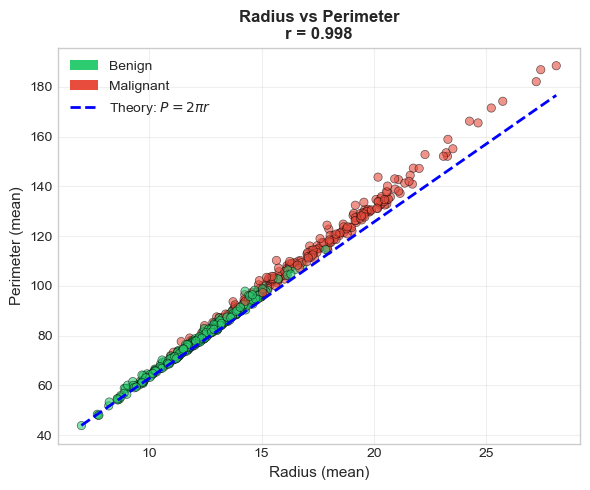

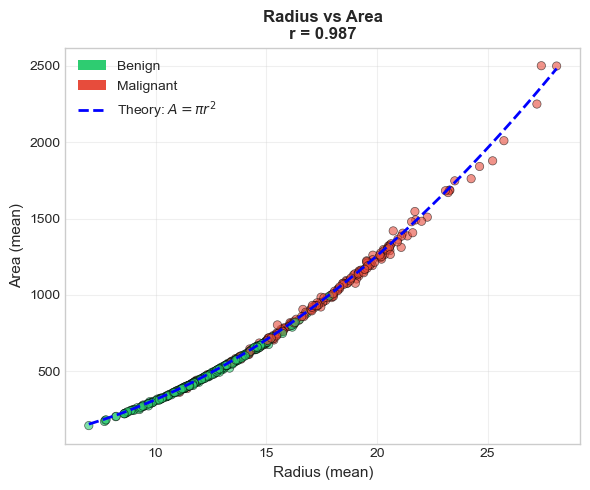

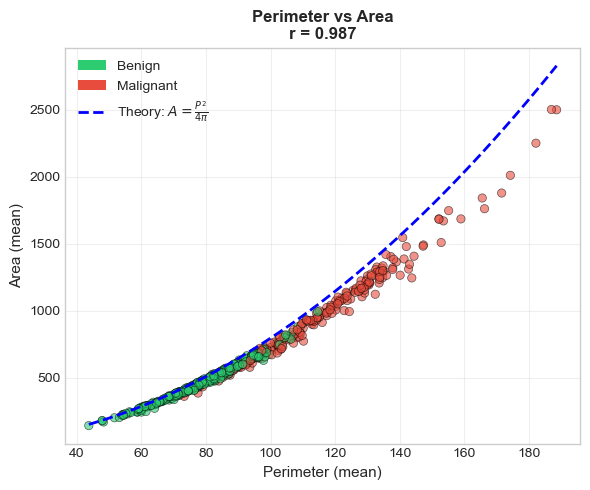

In [40]:
# Plot 1: Radius vs Perimeter
plt.figure(figsize=(6, 5))
colors_scatter = ['#e74c3c' if d == 'Malignant' else '#2ecc71' for d in df['diagnosis']]
plt.scatter(radius, perimeter, c=colors_scatter, alpha=0.6, edgecolors='black', linewidths=0.5)
r_range = np.linspace(radius.min(), radius.max(), 100)
plt.plot(r_range, 2 * np.pi * r_range, 'b--', linewidth=2, label=r'Theory: $P = 2\pi r$')
plt.xlabel('Radius (mean)', fontsize=11)
plt.ylabel('Perimeter (mean)', fontsize=11)
plt.title(f'Radius vs Perimeter\nr = {corr_r_p:.3f}', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Benign'),
                   Patch(facecolor='#e74c3c', label='Malignant')]
plt.legend(handles=legend_elements + plt.gca().get_legend_handles_labels()[0])
plt.tight_layout()
plt.show()

# Plot 2: Radius vs Area
plt.figure(figsize=(6, 5))
plt.scatter(radius, area, c=colors_scatter, alpha=0.6, edgecolors='black', linewidths=0.5)
plt.plot(r_range, np.pi * r_range**2, 'b--', linewidth=2, label=r'Theory: $A = \pi r^2$')
plt.xlabel('Radius (mean)', fontsize=11)
plt.ylabel('Area (mean)', fontsize=11)
plt.title(f'Radius vs Area\nr = {corr_r_a:.3f}', fontweight='bold')
plt.legend(handles=legend_elements + plt.gca().get_legend_handles_labels()[0])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Perimeter vs Area
plt.figure(figsize=(6, 5))
plt.scatter(perimeter, area, c=colors_scatter, alpha=0.6, edgecolors='black', linewidths=0.5)
p_range = np.linspace(perimeter.min(), perimeter.max(), 100)
plt.plot(p_range, p_range**2 / (4 * np.pi), 'b--', linewidth=2, label=r'Theory: $A = \frac{P^2}{4\pi}$')
plt.xlabel('Perimeter (mean)', fontsize=11)
plt.ylabel('Area (mean)', fontsize=11)
plt.title(f'Perimeter vs Area\nr = {corr_p_a:.3f}', fontweight='bold')
plt.legend(handles=legend_elements + plt.gca().get_legend_handles_labels()[0])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# Single example: Demonstrate with one data point
example_idx = 0
r_example = radius.iloc[example_idx]
p_actual = perimeter.iloc[example_idx]
a_actual = area.iloc[example_idx]
diagnosis_example = df['diagnosis'].iloc[example_idx]

# Calculate theoretical values
p_theoretical = 2 * np.pi * r_example
a_theoretical = np.pi * r_example**2

print("=" * 70)
print("SINGLE EXAMPLE: Sample #1")
print("=" * 70)
print(f"\n🔬 Diagnosis: {diagnosis_example}")
print(f"\n📏 Measured Values:")
print(f"   Radius:    {r_example:.2f}")
print(f"   Perimeter: {p_actual:.2f}")
print(f"   Area:      {a_actual:.2f}")

print(f"\n📐 Theoretical Values (assuming perfect circle):")
print(f"   Perimeter (2πr):  {p_theoretical:.2f}  (actual: {p_actual:.2f}, error: {abs(p_actual-p_theoretical)/p_actual*100:.1f}%)")
print(f"   Area (πr²):       {a_theoretical:.2f}  (actual: {a_actual:.2f}, error: {abs(a_actual-a_theoretical)/a_actual*100:.1f}%)")

print(f"\n💡 CONCLUSION:")
print(f"   Given ONLY the radius ({r_example:.2f}), we can predict:")
print(f"   - Perimeter within ~{abs(p_actual-p_theoretical)/p_actual*100:.0f}% accuracy")
print(f"   - Area within ~{abs(a_actual-a_theoretical)/a_actual*100:.0f}% accuracy")
print(f"   → These features are REDUNDANT for machine learning!")

SINGLE EXAMPLE: Sample #1

🔬 Diagnosis: Malignant

📏 Measured Values:
   Radius:    17.99
   Perimeter: 122.80
   Area:      1001.00

📐 Theoretical Values (assuming perfect circle):
   Perimeter (2πr):  113.03  (actual: 122.80, error: 8.0%)
   Area (πr²):       1016.75  (actual: 1001.00, error: 1.6%)

💡 CONCLUSION:
   Given ONLY the radius (17.99), we can predict:
   - Perimeter within ~8% accuracy
   - Area within ~2% accuracy
   → These features are REDUNDANT for machine learning!


In [14]:
# Quantify total redundancy: How much variance do radius/perimeter/area share?
# Extract just the three geometric features (mean values)
geometric_features = df[['mean radius', 'mean perimeter', 'mean area']].values

# Standardize
scaler_geo = StandardScaler()
geometric_scaled = scaler_geo.fit_transform(geometric_features)

# Apply PCA
pca_geo = PCA(n_components=3, random_state=RANDOM_STATE)
pca_geo.fit(geometric_scaled)

print("=" * 70)
print("PCA ON GEOMETRIC FEATURES ONLY (radius, perimeter, area)")
print("=" * 70)
print(f"\n📊 Explained Variance Ratio:")
for i, var in enumerate(pca_geo.explained_variance_ratio_, 1):
    cumvar = sum(pca_geo.explained_variance_ratio_[:i])
    bar = '█' * int(var * 50)
    print(f"   PC{i}: {var:6.2%} {bar:<50} (cumulative: {cumvar:.2%})")

print(f"\n💡 KEY INSIGHT:")
print(f"   PC1 alone captures {pca_geo.explained_variance_ratio_[0]:.1%} of variance!")
print(f"   This proves that 3 features can be represented by ~1 component.")
print(f"   → {(1 - 1/3)*100:.0f}% dimensionality reduction with <{(1-pca_geo.explained_variance_ratio_[0])*100:.1f}% information loss")

PCA ON GEOMETRIC FEATURES ONLY (radius, perimeter, area)

📊 Explained Variance Ratio:
   PC1: 99.37% █████████████████████████████████████████████████  (cumulative: 99.37%)
   PC2:  0.56%                                                    (cumulative: 99.93%)
   PC3:  0.07%                                                    (cumulative: 100.00%)

💡 KEY INSIGHT:
   PC1 alone captures 99.4% of variance!
   This proves that 3 features can be represented by ~1 component.
   → 67% dimensionality reduction with <0.6% information loss


#### Summary: Why This Matters

The analysis above demonstrates three levels of understanding:

| Level | Finding | Implication |
|-------|---------|-------------|
| **Big Picture** | High multicollinearity means redundant information | PCA can significantly reduce dimensions |
| **Mathematical Proof** | Geometric relationships ($P=2\pi r$, $A=\pi r^2$) create deterministic dependencies | These features are *mathematically* constrained to be correlated |
| **Empirical Evidence** | Single PC captures ~99% of geometric feature variance | In practice, 3 features → 1 component with minimal loss |

**This pattern repeats** across the dataset:
- `radius_mean`, `radius_se`, `radius_worst` are correlated (same measurement, different statistics)
- `compactness`, `concavity`, `concave points` describe similar shape properties
- `texture_mean`, `texture_se`, `texture_worst` capture the same underlying characteristic

**Result:** The 30-dimensional feature space likely has an **effective dimensionality** of far fewer components, making aggressive PCA reduction possible without sacrificing classification performance.

<a id="4-preprocessing"></a>
## 4. Data Preprocessing

### 4.1 Target Encoding

For this analysis, we define **Malignant (M) as the positive class (1)** since it's the critical class we want to detect. The original dataset encodes:
- 0 = Malignant
- 1 = Benign

We'll use `LabelEncoder` to remap: **Benign → 0, Malignant → 1**

In [15]:
# Encode target: Malignant (M) = 1 (positive class), Benign (B) = 0
encoder = LabelEncoder()
encoder.fit(['B', 'M'])  # Alphabetical: B=0, M=1

# Map original targets to string labels, then encode
# Original: 0=Malignant, 1=Benign → Need: M=1, B=0
target_names_mapped = np.array(['M', 'B'])[y]  # Convert to M/B labels
y = encoder.transform(target_names_mapped)

# Verify encoding
print("🏷️ Target Encoding Verification:")
print(f"   Classes: {encoder.classes_}")
print(f"   Benign (B) → {encoder.transform(['B'])[0]}")
print(f"   Malignant (M) → {encoder.transform(['M'])[0]}")
print(f"\n   Class distribution after encoding:")
print(f"   - Class 0 (Benign):    {np.sum(y == 0)}")
print(f"   - Class 1 (Malignant): {np.sum(y == 1)} ← Positive class for recall")

🏷️ Target Encoding Verification:
   Classes: ['B' 'M']
   Benign (B) → 0
   Malignant (M) → 1

   Class distribution after encoding:
   - Class 0 (Benign):    357
   - Class 1 (Malignant): 212 ← Positive class for recall


### 4.2 Train-Test Split

We use stratified sampling to maintain class proportions in both training and test sets.

In [16]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("📊 Train-Test Split Summary:")
print(f"   Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n   Training class distribution:")
print(f"   - Class 0 (Benign):    {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"   - Class 1 (Malignant): {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"\n   Test class distribution:")
print(f"   - Class 0 (Benign):    {np.sum(y_test == 0)} ({np.sum(y_test == 0)/len(y_test)*100:.1f}%)")
print(f"   - Class 1 (Malignant): {np.sum(y_test == 1)} ({np.sum(y_test == 1)/len(y_test)*100:.1f}%)")

📊 Train-Test Split Summary:
   Training set: 455 samples (80.0%)
   Test set:     114 samples (20.0%)

   Training class distribution:
   - Class 0 (Benign):    285 (62.6%)
   - Class 1 (Malignant): 170 (37.4%)

   Test class distribution:
   - Class 0 (Benign):    72 (63.2%)
   - Class 1 (Malignant): 42 (36.8%)


<a id="5-baseline"></a>
## 5. Baseline Model

### 5.1 Model Architecture

We establish a baseline using a Support Vector Machine (SVM) with:
- **Kernel:** Linear (interpretable, works well for high-dimensional data)
- **Class Weight:** Balanced (to handle class imbalance)
- **Preprocessing:** StandardScaler (essential for SVM as it's sensitive to feature scales)

In [17]:
# Create baseline pipeline (StandardScaler + SVM)
baseline_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE))
])

print("📐 Baseline Pipeline Architecture:")
print(baseline_pipe)

📐 Baseline Pipeline Architecture:
Pipeline(steps=[('scaler', StandardScaler()),
                ('svm',
                 SVC(class_weight='balanced', kernel='linear',
                     random_state=42))])


### 5.2 Train and Evaluate Baseline

BASELINE MODEL RESULTS (30 Features)

📊 Performance Metrics:
   Recall (Sensitivity):  0.9524
   Precision:             0.9756
   F1-Score:              0.9639

📋 Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



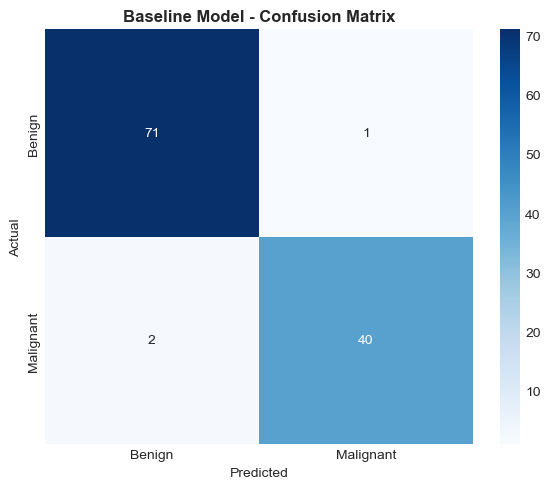

In [18]:
# Train baseline model
baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)

# Calculate metrics
baseline_recall = recall_score(y_test, y_pred_base)
baseline_precision = precision_score(y_test, y_pred_base)
baseline_f1 = f1_score(y_test, y_pred_base)

print("=" * 60)
print("BASELINE MODEL RESULTS (30 Features)")
print("=" * 60)
print(f"\n📊 Performance Metrics:")
print(f"   Recall (Sensitivity):  {baseline_recall:.4f}")
print(f"   Precision:             {baseline_precision:.4f}")
print(f"   F1-Score:              {baseline_f1:.4f}")

# Confusion Matrix
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Benign', 'Malignant']))

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'], ax=ax)
plt.title('Baseline Model - Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

<a id="6-pca"></a>
## 6. PCA Dimensionality Reduction Analysis

### 6.1 Methodology

We systematically evaluate the impact of PCA dimensionality reduction on classification performance by:
1. Training separate SVM models for each k (1 to 30 components)
2. Measuring recall at each k value
3. Computing "recall cost" = baseline_recall - reduced_recall
4. Analyzing the trade-off between variance retention and recall

### 6.2 PCA Visualization: 2D Projection & Scree Plot

Before sweeping all component counts, we first visualize the data projected onto its first two principal components and examine the scree plot to understand variance distribution.

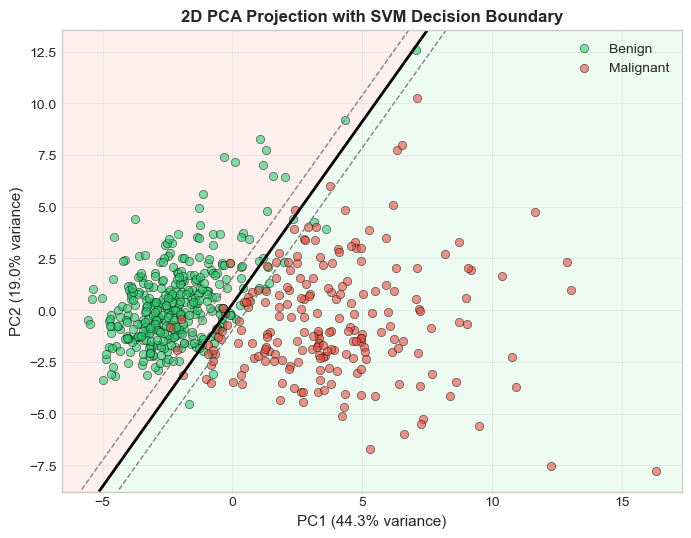

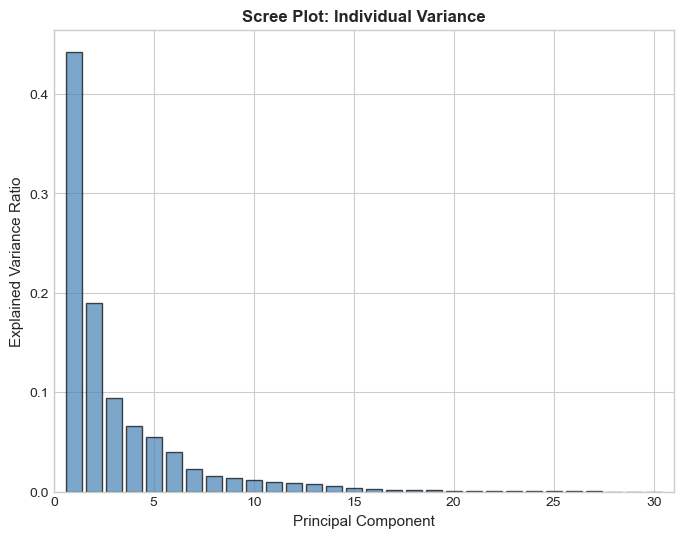

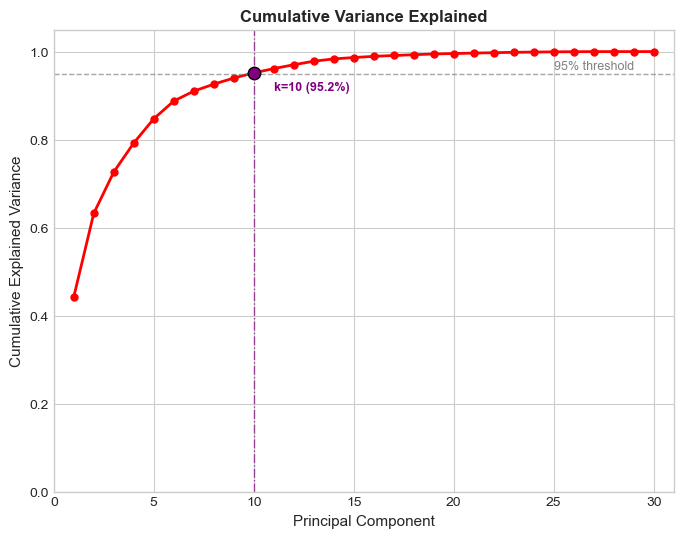


📊 PCA Summary:
   PC1 explains 44.3% of total variance
   PC1 + PC2 explain 63.2% of total variance
   10 components needed to reach 95% cumulative variance


In [39]:
# Fit PCA on scaled training data for visualization
scaler_vis = StandardScaler()
X_scaled_vis = scaler_vis.fit_transform(X)
pca_full = PCA(random_state=RANDOM_STATE).fit(X_scaled_vis)
X_pca_2d = pca_full.transform(X_scaled_vis)[:, :2]

# Fit an SVM on the 2D projection for decision boundary
svm_2d = SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE)
svm_2d.fit(X_pca_2d, y)

individual = pca_full.explained_variance_ratio_
cumulative = np.cumsum(individual)
components = range(1, len(individual) + 1)

# --- Plot 1: 2D PCA Scatter with Decision Boundary ---
plt.figure(figsize=(8, 6))
x_min, x_max = X_pca_2d[:, 0].min() - 1, X_pca_2d[:, 0].max() + 1
y_min, y_max = X_pca_2d[:, 1].min() - 1, X_pca_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], colors=['#e74c3c', '#2ecc71'], alpha=0.08)
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2, linestyles='-')
plt.contour(xx, yy, Z, levels=[-1, 1], colors='gray', linewidths=1, linestyles='--')

for label, color, name in [(0, '#2ecc71', 'Benign'), (1, '#e74c3c', 'Malignant')]:
    mask = y == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], c=color, label=name,
                alpha=0.6, edgecolors='black', linewidths=0.5)
plt.xlabel(f'PC1 ({individual[0]:.1%} variance)', fontsize=11)
plt.ylabel(f'PC2 ({individual[1]:.1%} variance)', fontsize=11)
plt.title('2D PCA Projection with SVM Decision Boundary', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- Plot 2: Scree Plot (Individual Variance) ---
plt.figure(figsize=(8, 6))
plt.bar(components, individual, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Principal Component', fontsize=11)
plt.ylabel('Explained Variance Ratio', fontsize=11)
plt.title('Scree Plot: Individual Variance', fontweight='bold')
plt.xlim(0, 31)
plt.show()

# --- Plot 3: Cumulative Explained Variance ---
plt.figure(figsize=(8, 6))
plt.plot(components, cumulative, color='red', linewidth=2, marker='o', markersize=5)
plt.axhline(0.95, color='gray', linestyle='--', alpha=0.7, linewidth=1)
k_95 = np.argmax(cumulative >= 0.95) + 1
plt.axvline(k_95, color='purple', linestyle='-.', alpha=0.7, linewidth=1)
plt.scatter([k_95], [cumulative[k_95 - 1]], color='purple', s=80, zorder=5, edgecolors='black')
plt.text(k_95 + 1, cumulative[k_95 - 1] - 0.04, f'k={k_95} ({cumulative[k_95 - 1]:.1%})',
         fontsize=9, color='purple', fontweight='bold')
plt.text(25, 0.96, '95% threshold', fontsize=9, color='gray')
plt.xlabel('Principal Component', fontsize=11)
plt.ylabel('Cumulative Explained Variance', fontsize=11)
plt.title('Cumulative Variance Explained', fontweight='bold')
plt.xlim(0, 31)
plt.ylim(0, 1.05)
plt.show()

# Print summary
print(f"\n📊 PCA Summary:")
print(f"   PC1 explains {individual[0]:.1%} of total variance")
print(f"   PC1 + PC2 explain {cumulative[1]:.1%} of total variance")
print(f"   {k_95} components needed to reach 95% cumulative variance")

### 6.3 PCA Component Sweep

In [20]:
# Sweep through all possible PCA components
results = []
components_range = range(1, X.shape[1] + 1)

print("🔄 Running PCA component sweep...")
for k in tqdm(components_range):
    # Create pipeline with k components
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=k, random_state=RANDOM_STATE)),
        ('svm', SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE))
    ])
    
    # Train and evaluate
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    
    # Get explained variance
    pca_step = pipeline.named_steps['pca']
    cum_var = np.sum(pca_step.explained_variance_ratio_)

    # Calculate metrics
    recall_cost = 1 - (rec / baseline_recall) # recall_cost = baseline_recall - rec (absolute difference)
    results.append({
        'k_components': k,
        'cumulative_variance': cum_var,
        'recall': rec,
        'precision': prec,
        'recall_cost': recall_cost
    })

print("✅ PCA sweep complete!")

# Create results DataFrame
df_results = pd.DataFrame(results)

🔄 Running PCA component sweep...


  0%|          | 0/30 [00:00<?, ?it/s]

✅ PCA sweep complete!


### 6.4 Results Summary Table

In [21]:
def interpret_recall_cost(cost, tolerance=0.001):
    """Categorize recall cost into interpretable labels."""
    if abs(cost) < tolerance:
        return "✅ Neutral"
    elif cost > 0:
        return "⚠️ Degradation"
    else:
        return "🎯 Improvement"

In [22]:
# Add the label column to df_results
df_results['interpretation'] = df_results['recall_cost'].apply(interpret_recall_cost)

# Display results table with styling
styled_df = df_results.style.background_gradient(
    subset=['cumulative_variance'], cmap='Blues'
).background_gradient(
    subset=['recall'], cmap='Greens'
).background_gradient(
    subset=['recall_cost'], cmap='RdYlGn_r'
).format({
    'cumulative_variance': '{:.4f}',
    'recall': '{:.4f}',
    'precision': '{:.4f}',
    'recall_cost': '{:.4f}'
})

print("📊 PCA Component Analysis Results")
print("\n📖 Legend:")
print("   ✅ Neutral     → RCR ≈ 0 (No performance change)")
print("   ⚠️ Degradation → RCR > 0 (Recall decreased)")
print("   🎯 Improvement → RCR < 0 (Recall increased, noise filtered)")
display(styled_df)

📊 PCA Component Analysis Results

📖 Legend:
   ✅ Neutral     → RCR ≈ 0 (No performance change)
   ⚠️ Degradation → RCR > 0 (Recall decreased)
   🎯 Improvement → RCR < 0 (Recall increased, noise filtered)


,k_components,cumulative_variance,recall,precision,recall_cost,interpretation
0,1,0.4459,0.8810,0.8810,0.0750,⚠️ Degradation
1,2,0.6314,0.9762,0.9535,-0.0250,🎯 Improvement
2,3,0.7272,0.9524,0.9524,0.0000,✅ Neutral
3,4,0.7932,0.9524,0.9524,0.0000,✅ Neutral
4,5,0.8494,0.9524,0.9091,0.0000,✅ Neutral
5,6,0.8893,0.9524,0.9302,0.0000,✅ Neutral
6,7,0.9114,0.9524,0.9091,0.0000,✅ Neutral
7,8,0.9276,0.9762,0.9535,-0.0250,🎯 Improvement
8,9,0.9404,0.9762,1.0000,-0.0250,🎯 Improvement
9,10,0.9521,0.9762,0.9762,-0.0250,🎯 Improvement


### 6.5 Visualization: Recall Cost vs. Information Retention

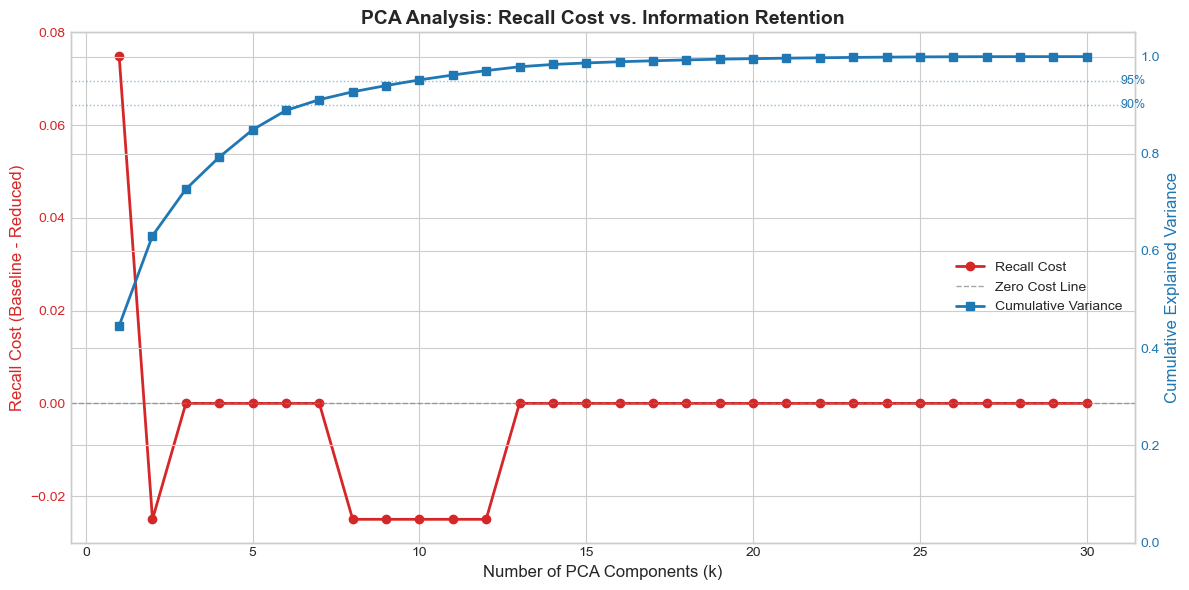

In [23]:
# Dual-axis plot: Recall Cost vs Cumulative Variance
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left axis: Recall Cost
color = 'tab:red'
ax1.set_xlabel('Number of PCA Components (k)', fontsize=12)
ax1.set_ylabel('Recall Cost (Baseline - Reduced)', color=color, fontsize=12)
line1 = ax1.plot(df_results['k_components'], df_results['recall_cost'], 
                  color=color, marker='o', linewidth=2, markersize=6, label='Recall Cost')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Zero Cost Line')

# Right axis: Cumulative Variance
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Cumulative Explained Variance', color=color, fontsize=12)
line2 = ax2.plot(df_results['k_components'], df_results['cumulative_variance'], 
                  color=color, marker='s', linewidth=2, markersize=6, label='Cumulative Variance')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1.05)

# Add variance threshold lines
ax2.axhline(0.90, color='tab:blue', linestyle=':', alpha=0.5, linewidth=1)
ax2.axhline(0.95, color='tab:blue', linestyle=':', alpha=0.5, linewidth=1)
ax2.text(31, 0.90, '90%', va='center', color='tab:blue', fontsize=9)
ax2.text(31, 0.95, '95%', va='center', color='tab:blue', fontsize=9)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('PCA Analysis: Recall Cost vs. Information Retention', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.grid(True, axis='x', alpha=0.3)
plt.show()

#### RCR Zone Analysis

The bar chart below maps each component count to its RCR value, with the three interpretive zones (Sensitivity Tax, Neutral, Sensitivity Rebate) clearly shaded.

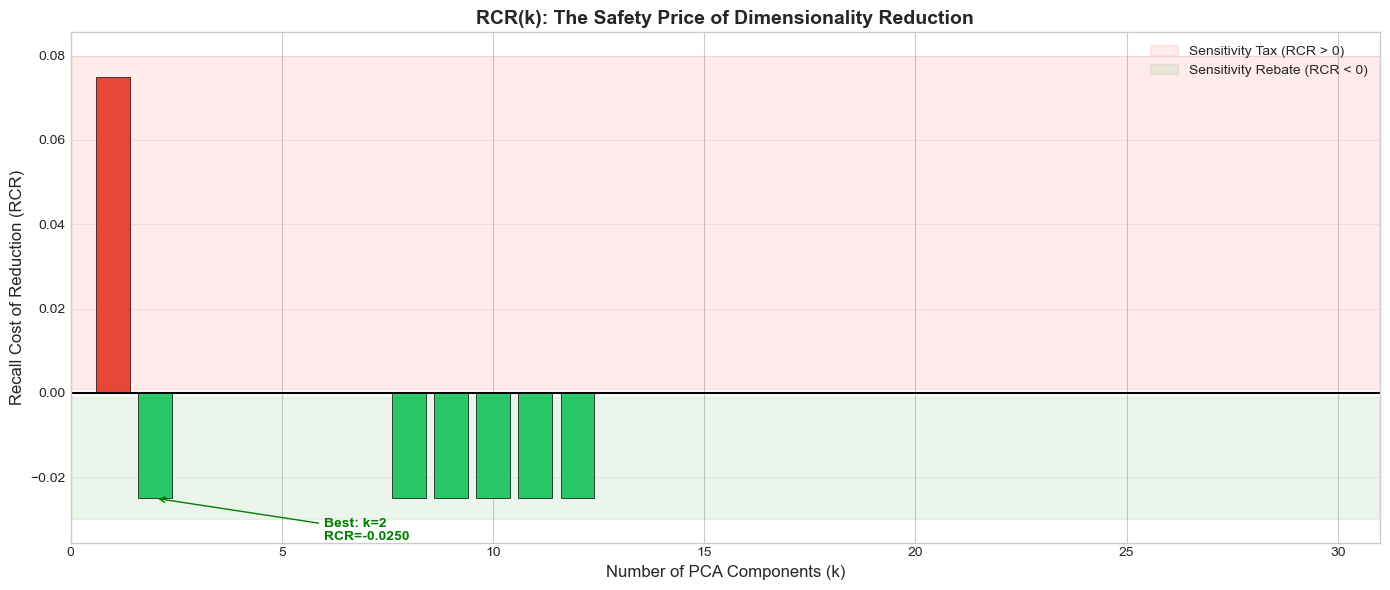

In [24]:
# Dedicated RCR bar chart with interpretive zones
fig, ax = plt.subplots(figsize=(14, 6))

# Color bars by RCR zone
bar_colors = ['#e74c3c' if r > 0.001 else '#2ecc71' if r < -0.001 else '#3498db'
              for r in df_results['recall_cost']]
ax.bar(df_results['k_components'], df_results['recall_cost'], color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=1.5)

# Shade zones
ylim = ax.get_ylim()
ax.axhspan(0.001, ylim[1] if ylim[1] > 0.001 else 0.05, alpha=0.08, color='red', label='Sensitivity Tax (RCR > 0)')
ax.axhspan(ylim[0] if ylim[0] < -0.001 else -0.05, -0.001, alpha=0.08, color='green', label='Sensitivity Rebate (RCR < 0)')

# Annotate best and worst
best_idx = df_results['recall_cost'].idxmin()
worst_idx = df_results['recall_cost'].idxmax()
ax.annotate(f"Best: k={df_results.loc[best_idx, 'k_components']}\nRCR={df_results.loc[best_idx, 'recall_cost']:.4f}",
            xy=(df_results.loc[best_idx, 'k_components'], df_results.loc[best_idx, 'recall_cost']),
            xytext=(df_results.loc[best_idx, 'k_components'] + 4, df_results.loc[best_idx, 'recall_cost'] - 0.01),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=10, color='green', fontweight='bold')

ax.set_xlabel('Number of PCA Components (k)', fontsize=12)
ax.set_ylabel('Recall Cost of Reduction (RCR)', fontsize=12)
ax.set_title('RCR(k): The Safety Price of Dimensionality Reduction', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.set_xlim(0, 31)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 6.6 Recall Threshold Analysis

We define an acceptable recall threshold as 95% of the baseline recall and visualize which component counts meet this criterion.

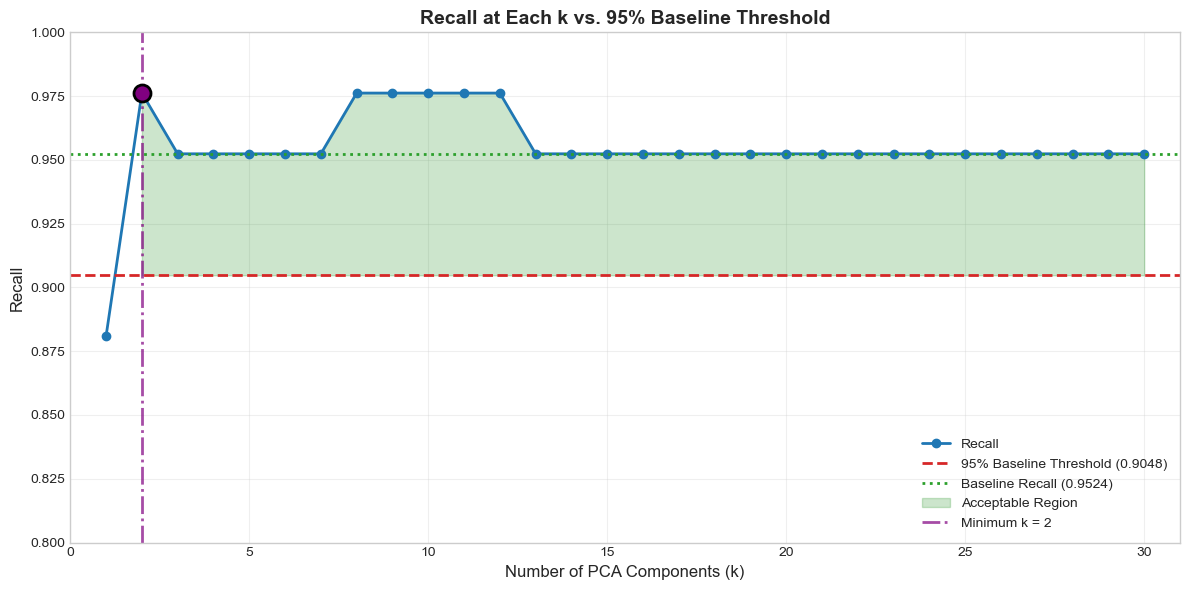


📌 Threshold Analysis Summary:
   Baseline Recall: 0.9524
   95% Threshold: 0.9048
   Minimum k meeting threshold: k = 2
   Recall at k=2: 0.9762
   Variance at k=2: 63.14%


In [25]:
# Recall vs Threshold Analysis
THRESHOLD_PERCENT = 0.95
threshold = THRESHOLD_PERCENT * baseline_recall

fig, ax = plt.subplots(figsize=(12, 6))

# Plot recall at each k
ax.plot(df_results['k_components'], df_results['recall'], 
        color='tab:blue', marker='o', linewidth=2, markersize=6, label='Recall')

# Plot threshold lines
ax.axhline(threshold, color='tab:red', linestyle='--', linewidth=2, 
           label=f'{THRESHOLD_PERCENT:.0%} Baseline Threshold ({threshold:.4f})')
ax.axhline(baseline_recall, color='tab:green', linestyle=':', linewidth=2,
           label=f'Baseline Recall ({baseline_recall:.4f})')

# Shade acceptable region
ax.fill_between(df_results['k_components'], threshold, df_results['recall'], 
                where=(df_results['recall'] >= threshold),
                color='green', alpha=0.2, label='Acceptable Region')

# Mark minimum k meeting threshold
acceptable_k = df_results[df_results['recall'] >= threshold]['k_components'].min()
ax.axvline(acceptable_k, color='purple', linestyle='-.', linewidth=2, alpha=0.7,
           label=f'Minimum k = {acceptable_k}')
ax.scatter([acceptable_k], [df_results[df_results['k_components'] == acceptable_k]['recall'].values[0]], 
           color='purple', s=150, zorder=5, edgecolors='black', linewidths=2)

ax.set_xlabel('Number of PCA Components (k)', fontsize=12)
ax.set_ylabel('Recall', fontsize=12)
ax.set_title(f'Recall at Each k vs. {THRESHOLD_PERCENT:.0%} Baseline Threshold', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 31)
ax.set_ylim(0.8, 1.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n📌 Threshold Analysis Summary:")
print(f"   Baseline Recall: {baseline_recall:.4f}")
print(f"   {THRESHOLD_PERCENT:.0%} Threshold: {threshold:.4f}")
print(f"   Minimum k meeting threshold: k = {acceptable_k}")
print(f"   Recall at k={acceptable_k}: {df_results[df_results['k_components'] == acceptable_k]['recall'].values[0]:.4f}")
print(f"   Variance at k={acceptable_k}: {df_results[df_results['k_components'] == acceptable_k]['cumulative_variance'].values[0]:.2%}")

### 6.7 Key Findings Summary

In [26]:
# Comprehensive Analysis Summary
print("=" * 70)
print("PCA DIMENSIONALITY REDUCTION - COMPREHENSIVE ANALYSIS")
print("=" * 70)

# Baseline
print(f"\n📊 BASELINE MODEL (30 features):")
print(f"   Recall: {baseline_recall:.4f}")
print(f"   Precision: {baseline_precision:.4f}")
print(f"   F1-Score: {baseline_f1:.4f}")

# Find key statistics
best_recall = df_results['recall'].max()
best_k = df_results[df_results['recall'] == best_recall]['k_components'].min()
best_variance = df_results[df_results['k_components'] == best_k]['cumulative_variance'].values[0]

print(f"\n🏆 BEST PERFORMING CONFIGURATION:")
print(f"   k = {best_k} components")
print(f"   Recall: {best_recall:.4f} (Δ = {best_recall - baseline_recall:+.4f})")
print(f"   Cumulative Variance: {best_variance:.2%}")
print(f"   Dimensionality Reduction: {(30 - best_k)/30:.1%}")

# Minimum k with no recall cost
no_cost_df = df_results[df_results['recall'] >= baseline_recall]
if not no_cost_df.empty:
    min_k_no_cost = no_cost_df['k_components'].min()
    var_at_min_k = no_cost_df[no_cost_df['k_components'] == min_k_no_cost]['cumulative_variance'].values[0]
    print(f"\n✅ MINIMUM k WITH NO RECALL LOSS:")
    print(f"   k = {min_k_no_cost} components")
    print(f"   Cumulative Variance: {var_at_min_k:.2%}")
    print(f"   Dimensionality Reduction: {(30 - min_k_no_cost)/30:.1%}")

# Variance threshold analysis
print(f"\n📈 VARIANCE THRESHOLD ANALYSIS:")
print(f"   {'Threshold':<15} {'k':<5} {'Recall':<10} {'Cost':<10}")
print(f"   {'-'*40}")
for threshold_val in [0.90, 0.95, 0.99]:
    k_at_threshold = df_results[df_results['cumulative_variance'] >= threshold_val]['k_components'].min()
    recall_at_k = df_results[df_results['k_components'] == k_at_threshold]['recall'].values[0]
    cost_at_k = df_results[df_results['k_components'] == k_at_threshold]['recall_cost'].values[0]
    print(f"   {threshold_val:.0%} variance   {k_at_threshold:<5} {recall_at_k:<10.4f} {cost_at_k:<+10.4f}")

# Recommendation
print(f"\n" + "=" * 70)
print("💡 RECOMMENDATION")
print("=" * 70)
if not no_cost_df.empty:
    print(f"\n   For this dataset, you can safely reduce from 30 to {min_k_no_cost} components:")
    print(f"   • Retains {var_at_min_k:.2%} of total variance")
    print(f"   • Achieves {(30 - min_k_no_cost)/30:.1%} dimensionality reduction")
    print(f"   • Maintains or improves recall performance")

PCA DIMENSIONALITY REDUCTION - COMPREHENSIVE ANALYSIS

📊 BASELINE MODEL (30 features):
   Recall: 0.9524
   Precision: 0.9756
   F1-Score: 0.9639

🏆 BEST PERFORMING CONFIGURATION:
   k = 2 components
   Recall: 0.9762 (Δ = +0.0238)
   Cumulative Variance: 63.14%
   Dimensionality Reduction: 93.3%

✅ MINIMUM k WITH NO RECALL LOSS:
   k = 2 components
   Cumulative Variance: 63.14%
   Dimensionality Reduction: 93.3%

📈 VARIANCE THRESHOLD ANALYSIS:
   Threshold       k     Recall     Cost      
   ----------------------------------------
   90% variance   7     0.9524     +0.0000   
   95% variance   10    0.9762     -0.0250   
   99% variance   17    0.9524     +0.0000   

💡 RECOMMENDATION

   For this dataset, you can safely reduce from 30 to 2 components:
   • Retains 63.14% of total variance
   • Achieves 93.3% dimensionality reduction
   • Maintains or improves recall performance


### 6.8 Interpretation of Results

**Key Observations:**

1. **Non-linear Relationship:** The relationship between number of components and recall is not monotonic—more features don't necessarily mean better performance.

2. **"Free Lunch" Zone:** For the first several components (approximately k=2 to k=12), the recall cost is near zero or even negative (improvement). This occurs because:
   - The dataset exhibits high multicollinearity (radius, perimeter, area are mathematically related)
   - PCA consolidates redundant information, effectively denoising the data
   - Removing noise can actually improve recall by preventing overfitting

3. **Tipping Point:** There's a critical threshold where recall begins to degrade significantly. This represents the point where we start discarding signal rather than noise. For this dataset, this typically occurs when cumulative variance drops below ~90-95%.

4. **Practical Implications:**
   - Set an acceptable recall tolerance (e.g., 98% of baseline)
   - Find the minimum k that meets this threshold
   - Verify cumulative variance is still reasonably high for model stability on unseen data

### 6.9 Cross-Validation for Robustness

To ensure our findings are robust and not artifacts of the particular train-test split, we perform 5-fold stratified cross-validation.

In [27]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compute a proper CV baseline (no PCA, full 30 features)
baseline_cv_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE))
])
baseline_cv_scores = cross_val_score(baseline_cv_pipe, X, y, cv=cv, scoring='recall')
baseline_recall_cv = baseline_cv_scores.mean()
print(f"📊 CV Baseline Recall (30 features): {baseline_recall_cv:.4f} ± {baseline_cv_scores.std():.4f}")

cv_results = []
components_range = range(1, X.shape[1] + 1)

for k in tqdm(components_range):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=k, random_state=RANDOM_STATE)),
        ('svm', SVC(kernel='linear', class_weight='balanced', random_state=42))
    ])
    
    # Use cross-validation for more robust estimates
    cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='recall')
    
    # Fit once on full training set for variance calculation
    pipeline.fit(X_train, y_train)
    pca_step = pipeline.named_steps['pca']
    cum_var = np.sum(pca_step.explained_variance_ratio_)
    
    cv_results.append({
        'k_components': k,
        'cumulative_variance': cum_var,
        'recall_mean': cv_scores.mean(),
        'recall_std': cv_scores.std(),
        'recall_cost': 1 - (cv_scores.mean() / baseline_recall_cv)
    })

📊 CV Baseline Recall (30 features): 0.9623 ± 0.0380


  0%|          | 0/30 [00:00<?, ?it/s]

In [28]:
cv_results_df = pd.DataFrame(cv_results)
print(cv_results_df.to_string(index=False))

 k_components  cumulative_variance  recall_mean  recall_std  recall_cost
            1               0.4459       0.8960      0.0510       0.0689
            2               0.6314       0.9622      0.0384       0.0001
            3               0.7272       0.9622      0.0320       0.0001
            4               0.7932       0.9437      0.0581       0.0193
            5               0.8494       0.9484      0.0497       0.0145
            6               0.8893       0.9670      0.0242      -0.0048
            7               0.9114       0.9718      0.0176      -0.0098
            8               0.9276       0.9669      0.0355      -0.0047
            9               0.9404       0.9623      0.0239       0.0000
           10               0.9521       0.9576      0.0275       0.0049
           11               0.9622       0.9623      0.0380       0.0000
           12               0.9712       0.9671      0.0349      -0.0049
           13               0.9791       0.9625    

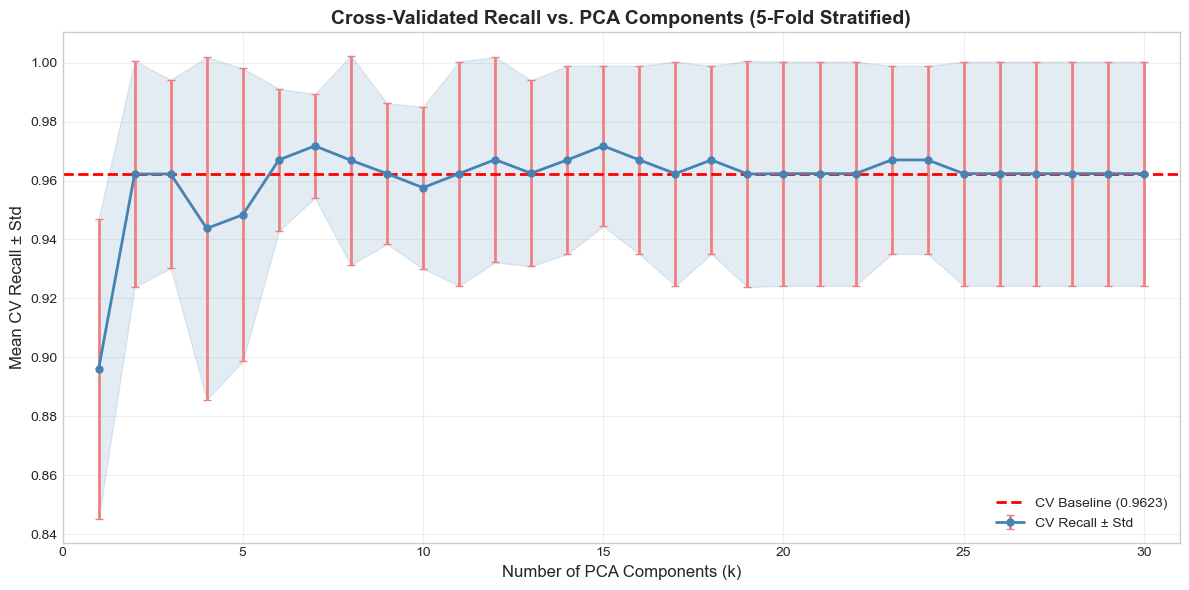


🏆 Best CV Configuration: k=7, Recall=0.9718, RCR=-0.0098


In [41]:
# Cross-validation results visualization with error bars
fig, ax = plt.subplots(figsize=(12, 6))

ax.errorbar(cv_results_df['k_components'], cv_results_df['recall_mean'],
            yerr=cv_results_df['recall_std'], marker='o', capsize=3, linewidth=2,
            color='steelblue', ecolor='lightcoral', markersize=5, label='CV Recall ± Std')
ax.axhline(baseline_recall_cv, color='red', linestyle='--', linewidth=2,
           label=f'CV Baseline ({baseline_recall_cv:.4f})')
ax.fill_between(cv_results_df['k_components'],
                cv_results_df['recall_mean'] - cv_results_df['recall_std'],
                cv_results_df['recall_mean'] + cv_results_df['recall_std'],
                alpha=0.15, color='steelblue')

ax.set_xlabel('Number of PCA Components (k)', fontsize=12)
ax.set_ylabel('Mean CV Recall ± Std', fontsize=12)
ax.set_title('Cross-Validated Recall vs. PCA Components (5-Fold Stratified)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, 31)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Identify best CV configuration
best_cv_idx = cv_results_df['recall_mean'].idxmax()
best_cv_k = cv_results_df.loc[best_cv_idx, 'k_components']
best_cv_recall = cv_results_df.loc[best_cv_idx, 'recall_mean']
best_cv_rcr = cv_results_df.loc[best_cv_idx, 'recall_cost']
print(f"\n🏆 Best CV Configuration: k={best_cv_k}, Recall={best_cv_recall:.4f}, RCR={best_cv_rcr:+.4f}")

<a id="7-optimization"></a>
## 7. Hyperparameter Optimization

### 7.1 Grid Search Cross-Validation

We optimize both PCA components and SVM hyperparameters simultaneously using GridSearchCV.

In [35]:
# Define parameter grid for joint optimization
param_grid = {
    'pca__n_components': [2, 3, 5, 7, 10, 15, 20],
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

# Create pipeline
opt_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=RANDOM_STATE)),
    ('svm', SVC(class_weight='balanced', random_state=RANDOM_STATE))
])

# Grid search with cross-validation
print("🔍 Running Grid Search (this may take a moment)...")
grid_search = GridSearchCV(
    opt_pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

# Results
print(f"\n{'='*60}")
print("GRID SEARCH RESULTS")
print(f"{'='*60}")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
# Calculate mean and std of cross-validation recall scores
cv_scores = grid_search.cv_results_['mean_test_score']
cv_std = grid_search.cv_results_['std_test_score']
best_idx = grid_search.best_index_
print(f"\n📊 Best CV Recall: {grid_search.best_score_:.4f} ± {cv_std[best_idx]:.4f}")

# Evaluate on test set
y_pred_grid = grid_search.predict(X_test)
grid_recall = recall_score(y_test, y_pred_grid)
grid_precision = precision_score(y_test, y_pred_grid)
grid_f1 = f1_score(y_test, y_pred_grid)
print(f"\n📋 Test Set Performance:")
print(f"   Recall:    {grid_recall:.4f}")
print(f"   Precision: {grid_precision:.4f}")
print(f"   F1-Score:  {grid_f1:.4f}")

🔍 Running Grid Search (this may take a moment)...
Fitting 5 folds for each of 350 candidates, totalling 1750 fits

GRID SEARCH RESULTS

🏆 Best Parameters:
   pca__n_components: 3
   svm__C: 0.1
   svm__gamma: 1
   svm__kernel: rbf

📊 Best CV Recall: 0.9824 ± 0.0144

📋 Test Set Performance:
   Recall:    1.0000
   Precision: 0.6462
   F1-Score:  0.7850


### 7.2 Randomized Search (Alternative Approach)

For larger parameter spaces, RandomizedSearchCV provides more efficient exploration.

In [31]:
# Randomized search with continuous distributions
param_distributions = {
    'pca__n_components': range(2, 25),
    'svm__C': loguniform(1e-3, 1e3),
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': loguniform(1e-4, 1e1)
}

rand_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(random_state=RANDOM_STATE)),
    ('svm', SVC(class_weight='balanced', random_state=RANDOM_STATE))
])

print("🎲 Running Randomized Search...")
random_search = RandomizedSearchCV(
    rand_pipeline,
    param_distributions,
    n_iter=100,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='recall',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)
random_search.fit(X_train, y_train)

print(f"\n{'='*60}")
print("RANDOMIZED SEARCH RESULTS")
print(f"{'='*60}")
print(f"\n🏆 Best Parameters:")
for param, value in random_search.best_params_.items():
    if isinstance(value, float):
        print(f"   {param}: {value:.6f}")
    else:
        print(f"   {param}: {value}")
print(f"\n📊 Best CV Recall: {random_search.best_score_:.4f}")

# Evaluate on test set
y_pred_rand = random_search.predict(X_test)
rand_recall = recall_score(y_test, y_pred_rand)
rand_precision = precision_score(y_test, y_pred_rand)
rand_f1 = f1_score(y_test, y_pred_rand)
print(f"\n📋 Test Set Performance:")
print(f"   Recall:    {rand_recall:.4f}")
print(f"   Precision: {rand_precision:.4f}")
print(f"   F1-Score:  {rand_f1:.4f}")

🎲 Running Randomized Search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

RANDOMIZED SEARCH RESULTS

🏆 Best Parameters:
   pca__n_components: 21
   svm__C: 0.293848
   svm__gamma: 0.314457
   svm__kernel: rbf

📊 Best CV Recall: 0.9824

📋 Test Set Performance:
   Recall:    0.9762
   Precision: 0.5942
   F1-Score:  0.7387


### 7.3 Hyperparameter Search Visualization

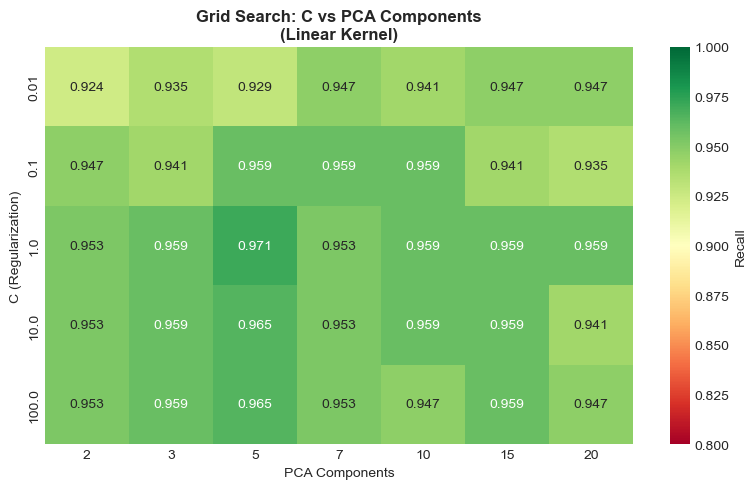

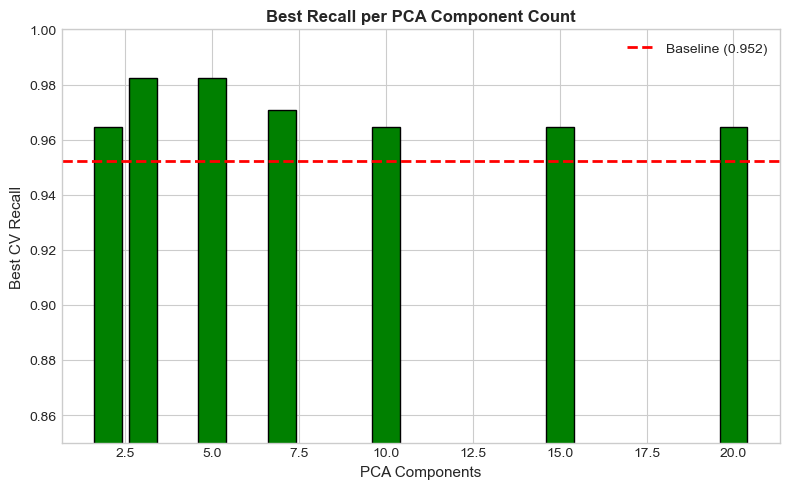

In [42]:
# Visualize grid search results
grid_cv_results = pd.DataFrame(grid_search.cv_results_)

# Plot 1: Heatmap for linear kernel - C vs n_components
plt.figure(figsize=(8, 5))
linear_results = grid_cv_results[grid_cv_results['param_svm__kernel'] == 'linear']
pivot_linear = linear_results.pivot_table(
    values='mean_test_score',
    index='param_svm__C',
    columns='param_pca__n_components'
)
sns.heatmap(pivot_linear, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0.8, vmax=1.0, cbar_kws={'label': 'Recall'})
plt.title('Grid Search: C vs PCA Components\n(Linear Kernel)', fontsize=12, fontweight='bold')
plt.xlabel('PCA Components')
plt.ylabel('C (Regularization)')
plt.tight_layout()
plt.show()

# Plot 2: Best recall per n_components
plt.figure(figsize=(8, 5))
best_per_k = grid_cv_results.groupby('param_pca__n_components')['mean_test_score'].max()
colors = ['green' if v >= baseline_recall else 'steelblue' for v in best_per_k.values]
plt.bar(best_per_k.index, best_per_k.values, color=colors, edgecolor='black')
plt.axhline(baseline_recall, color='red', linestyle='--', linewidth=2, label=f'Baseline ({baseline_recall:.3f})')
plt.xlabel('PCA Components', fontsize=11)
plt.ylabel('Best CV Recall', fontsize=11)
plt.title('Best Recall per PCA Component Count', fontsize=12, fontweight='bold')
plt.legend()
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()

<a id="8-results"></a>
## 8. Results & Discussion

### 8.1 Final Model Comparison

In [33]:
# Comprehensive model comparison including RCR
print("=" * 80)
print("FINAL MODEL COMPARISON")
print("=" * 80)

# Compute RCR for each optimized model
rcr_grid = 1 - (grid_recall / baseline_recall)
rcr_rand = 1 - (rand_recall / baseline_recall)

# Get optimal k values
optimal_k_grid = grid_search.best_params_['pca__n_components']
optimal_k_rand = random_search.best_params_['pca__n_components']

# Best unoptimized PCA model from sweep (Section 6)
best_sweep_idx = df_results['recall'].idxmax()
sweep_k = df_results.loc[best_sweep_idx, 'k_components']
sweep_recall = df_results.loc[best_sweep_idx, 'recall']
sweep_precision = df_results.loc[best_sweep_idx, 'precision']
sweep_f1 = f1_score(y_test,
    Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=sweep_k, random_state=RANDOM_STATE)),
        ('svm', SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE))
    ]).fit(X_train, y_train).predict(X_test))
rcr_sweep = 1 - (sweep_recall / baseline_recall)

# Build comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': [
        'Baseline (30 features)',
        f'PCA Sweep Best (k={sweep_k})',
        'Grid Search Optimized',
        'Random Search Optimized'
    ],
    'k': [30, sweep_k, optimal_k_grid, optimal_k_rand],
    'Recall': [baseline_recall, sweep_recall, grid_recall, rand_recall],
    'Precision': [baseline_precision, sweep_precision, grid_precision, rand_precision],
    'F1': [baseline_f1, sweep_f1, grid_f1, rand_f1],
    'RCR': [np.nan, rcr_sweep, rcr_grid, rcr_rand],
    'Reduction (%)': [0.0, (30 - sweep_k) / 30 * 100,
                      (30 - optimal_k_grid) / 30 * 100,
                      (30 - optimal_k_rand) / 30 * 100]
}).set_index('Model')

# Style and display
styled_comparison = (
    comparison_df.style
    .format({
        'Recall': '{:.4f}', 'Precision': '{:.4f}', 'F1': '{:.4f}',
        'RCR': '{:+.4f}', 'Reduction (%)': '{:.1f}%', 'k': '{:.0f}'
    }, na_rep='N/A')
    .background_gradient(subset=['Recall'], cmap='Greens')
    .background_gradient(subset=['RCR'], cmap='RdYlGn_r')
    .set_caption('Model Performance Comparison')
)
display(styled_comparison)

# RCR Interpretation
print(f"\n📐 RECALL COST OF REDUCTION (RCR) ANALYSIS:")
print(f"   Baseline Recall (R_n):  {baseline_recall:.4f}")

for name, rcr_val, k_val in [
    (f"PCA Sweep Best", rcr_sweep, sweep_k),
    ("Grid Search", rcr_grid, optimal_k_grid),
    ("Random Search", rcr_rand, optimal_k_rand)
]:
    if abs(rcr_val) < 0.001:
        interpretation = "Neutral Reduction — no recall change"
    elif rcr_val > 0:
        interpretation = f"Sensitivity Tax — {rcr_val:.2%} of baseline recall lost"
    else:
        interpretation = f"Sensitivity Rebate — {abs(rcr_val):.2%} improvement over baseline"
    print(f"\n   {name} (k={k_val}):")
    print(f"   RCR = {rcr_val:+.4f} → {interpretation}")

# Determine best model across all three
candidates = {
    f'PCA Sweep Best (k={sweep_k})': (sweep_recall, rcr_sweep, sweep_k, None),
    'Grid Search': (grid_recall, rcr_grid, optimal_k_grid, grid_search.best_params_),
    'Random Search': (rand_recall, rcr_rand, optimal_k_rand, random_search.best_params_),
}
best_model_name = max(candidates, key=lambda m: candidates[m][0])
best_recall, best_rcr, best_k, best_params = candidates[best_model_name]
reduction_pct = (30 - best_k) / 30 * 100

# Final recommendation
print(f"\n{'='*80}")
print("🎯 FINAL RECOMMENDATION")
print(f"{'='*80}")

if best_params is not None:
    print(f"""
   Based on our comprehensive analysis, the {best_model_name} model is recommended:
   
   1. Use PCA with k = {best_k} components ({reduction_pct:.1f}% reduction)
   2. SVM Configuration:
      - Kernel: {best_params['svm__kernel']}
      - C: {best_params['svm__C']}
      - Gamma: {best_params.get('svm__gamma', 'N/A')}
   
   Performance:
   - Recall: {best_recall:.4f} (vs baseline {baseline_recall:.4f})
   - RCR: {best_rcr:+.4f} ({'Sensitivity Rebate' if best_rcr < 0 else 'Sensitivity Tax' if best_rcr > 0 else 'Neutral'})
""")
else:
    print(f"""
   Based on our comprehensive analysis, the {best_model_name} model is recommended:
   
   1. Use PCA with k = {best_k} components ({reduction_pct:.1f}% reduction)
   2. SVM Configuration: Default (linear kernel, C=1, balanced class weights)
   
   Performance:
   - Recall: {best_recall:.4f} (vs baseline {baseline_recall:.4f})
   - RCR: {best_rcr:+.4f} ({'Sensitivity Rebate' if best_rcr < 0 else 'Sensitivity Tax' if best_rcr > 0 else 'Neutral'})
   
   Note: Hyperparameter optimization did not improve upon the default configuration.
""")

FINAL MODEL COMPARISON


,k,Recall,Precision,F1,RCR,Reduction (%)
Model,,,,,,
Baseline (30 features),30,0.9524,0.9756,0.9639,N/A,0.0%
PCA Sweep Best (k=2),2,0.9762,0.9535,0.9647,-0.0250,93.3%
Grid Search Optimized,3,1.0000,0.6462,0.7850,-0.0500,90.0%
Random Search Optimized,21,0.9762,0.5942,0.7387,-0.0250,30.0%



📐 RECALL COST OF REDUCTION (RCR) ANALYSIS:
   Baseline Recall (R_n):  0.9524

   PCA Sweep Best (k=2):
   RCR = -0.0250 → Sensitivity Rebate — 2.50% improvement over baseline

   Grid Search (k=3):
   RCR = -0.0500 → Sensitivity Rebate — 5.00% improvement over baseline

   Random Search (k=21):
   RCR = -0.0250 → Sensitivity Rebate — 2.50% improvement over baseline

🎯 FINAL RECOMMENDATION

   Based on our comprehensive analysis, the Grid Search model is recommended:
   
   1. Use PCA with k = 3 components (90.0% reduction)
   2. SVM Configuration:
      - Kernel: rbf
      - C: 0.1
      - Gamma: 1
   
   Performance:
   - Recall: 1.0000 (vs baseline 0.9524)
   - RCR: -0.0500 (Sensitivity Rebate)



### 8.2 Final Model Evaluation

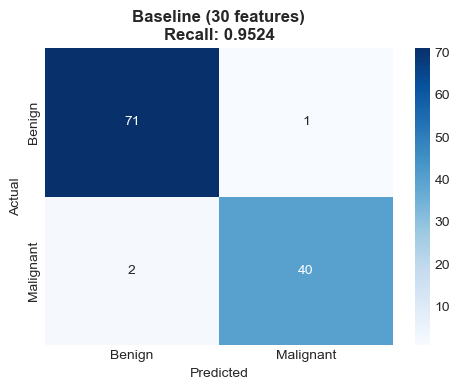

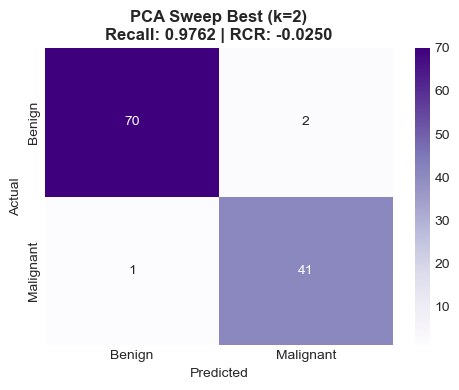

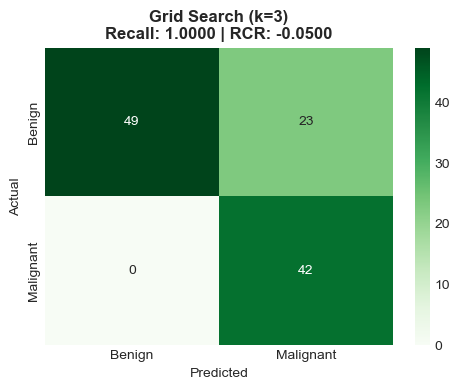

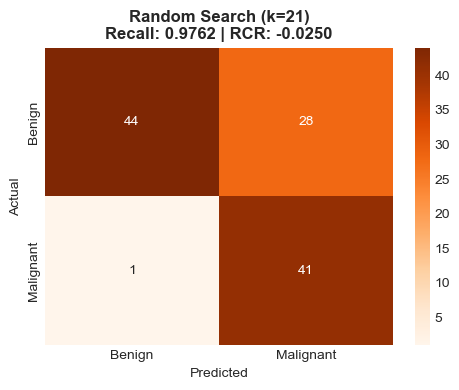


📋 DETAILED CLASSIFICATION REPORTS

Baseline Model (30 features):
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

PCA Sweep Best (k=2):
              precision    recall  f1-score   support

      Benign       0.99      0.97      0.98        72
   Malignant       0.95      0.98      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Grid Search Optimized (k=3):
              precision    recall  f1-score   support

      Benign       1.00      0.68      0.81        72
   Malignant       0.65      1.00      0.79        42

    accuracy                           0.80       114
   macro av

In [44]:
# Get PCA sweep predictions
sweep_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=sweep_k, random_state=RANDOM_STATE)),
    ('svm', SVC(kernel='linear', class_weight='balanced', random_state=RANDOM_STATE))
])
sweep_pipe.fit(X_train, y_train)
y_pred_sweep = sweep_pipe.predict(X_test)

# Baseline confusion matrix
plt.figure(figsize=(5, 4))
cm_base = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f'Baseline (30 features)\nRecall: {baseline_recall:.4f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# PCA Sweep confusion matrix
plt.figure(figsize=(5, 4))
cm_sweep = confusion_matrix(y_test, y_pred_sweep)
sns.heatmap(cm_sweep, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f'PCA Sweep Best (k={sweep_k})\nRecall: {sweep_recall:.4f} | RCR: {rcr_sweep:+.4f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Grid Search confusion matrix
plt.figure(figsize=(5, 4))
cm_grid = confusion_matrix(y_test, y_pred_grid)
sns.heatmap(cm_grid, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f'Grid Search (k={optimal_k_grid})\nRecall: {grid_recall:.4f} | RCR: {rcr_grid:+.4f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Random Search confusion matrix
plt.figure(figsize=(5, 4))
cm_rand = confusion_matrix(y_test, y_pred_rand)
sns.heatmap(cm_rand, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title(f'Random Search (k={optimal_k_rand})\nRecall: {rand_recall:.4f} | RCR: {rcr_rand:+.4f}', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Detailed classification reports
print("\n📋 DETAILED CLASSIFICATION REPORTS")
print("\n" + "="*40)
print("Baseline Model (30 features):")
print("="*40)
print(classification_report(y_test, y_pred_base, target_names=['Benign', 'Malignant']))
print("="*40)
print(f"PCA Sweep Best (k={sweep_k}):")
print("="*40)
print(classification_report(y_test, y_pred_sweep, target_names=['Benign', 'Malignant']))
print("="*40)
print(f"Grid Search Optimized (k={optimal_k_grid}):")
print("="*40)
print(classification_report(y_test, y_pred_grid, target_names=['Benign', 'Malignant']))
print("="*40)
print(f"Random Search Optimized (k={optimal_k_rand}):")
print("="*40)
print(classification_report(y_test, y_pred_rand, target_names=['Benign', 'Malignant']))

### 8.3 The Precision-Recall Trade-Off Under Compression

While PCA reduction maintains or improves recall, it comes at the cost of increased false positives (lower precision). This is visible in the confusion matrices: compressed models classify more benign tumors as malignant. In a clinical screening pipeline, this trade-off is acceptable — a false positive results in a follow-up biopsy, whereas a false negative represents a missed malignancy. The $RCR$ metric intentionally captures only the recall dimension of this trade-off because, in this domain, the cost asymmetry makes precision a secondary constraint rather than a co-equal objective.

However, excessive false positives carry their own costs: patient anxiety, unnecessary procedures, and healthcare resource utilization. A production system might pair this high-sensitivity screening model with a second-stage, high-precision confirmation model — a common two-stage diagnostic architecture.

<a id="9-conclusions"></a>
## 9. Conclusions

### 9.1 Summary of Findings

This project investigated the effectiveness of PCA dimensionality reduction for breast cancer classification using SVMs. Our key findings are:

1. **Significant Dimensionality Reduction is Possible:** We demonstrated that the Wisconsin Breast Cancer Dataset can be reduced from 30 features to as few as 2-7 PCA components while maintaining or improving classification recall.

2. **Multicollinearity Drives Effectiveness:** The dataset's high feature correlation (particularly among radius, perimeter, and area measurements) makes PCA highly effective. The first few principal components capture most discriminative information.

3. **Recall ≠ Variance Retention:** A key insight is that maximum variance retention doesn't necessarily optimize recall. Models with ~63% variance (k=2) can outperform models with 100% variance (k=30).

4. **Hyperparameter Optimization Matters:** Joint optimization of PCA components and SVM hyperparameters yields better results than optimizing either in isolation.

5. **Compression Shifts the Decision Boundary:** PCA reduction consistently improves recall at the expense of precision. By compressing the feature space, the SVM's decision boundary becomes more conservative — flagging borderline cases as malignant. This is the correct bias for a screening tool, but it does increase false positives that carry downstream costs (unnecessary biopsies, patient anxiety, and resource utilization).

### 9.2 Practical Implications

- **For Medical Diagnosis:** The optimized model maintains high sensitivity (recall) for malignant tumor detection, which is critical for clinical applications. However, the elevated false positive rate means this model is best suited as a **first-stage screening tool** rather than a standalone diagnostic system.
- **For Clinical Deployment:** A two-stage architecture is recommended: this high-sensitivity PCA-SVM model as the initial screen, followed by a high-precision confirmation model (or clinician review) for cases flagged as malignant. This mirrors standard clinical practice where screening and confirmatory testing serve complementary roles.
- **For Deployment:** Reduced dimensionality means faster inference and lower computational requirements.
- **For Interpretability:** Fewer components, while less directly interpretable, can be visualized in 2D/3D for exploratory analysis.

### 9.3 Limitations

1. **Single Dataset:** Results may not generalize to other medical imaging datasets.
2. **Fixed Test Set:** While we used cross-validation, a true external validation set would strengthen conclusions.
3. **Linear PCA Only:** Non-linear dimensionality reduction (e.g., t-SNE, UMAP, kernel PCA) was not explored.
4. **Precision Trade-Off:** While the $RCR$ metric captures the recall dimension of dimensionality reduction, we did not introduce a corresponding *Precision Cost of Reduction* ($PCR$) to formally measure the false positive trade-off. Future work could define $PCR(k) = 1 - \frac{P_k}{P_n}$ to provide a complete picture of the cost surface.

### 9.4 Future Work

- **Non-linear reduction:** Explore kernel PCA, t-SNE, and UMAP as alternatives to linear PCA.
- **Feature selection:** Compare PCA against filter/wrapper methods that preserve original feature interpretability.
- **Ensemble approaches:** Combine multiple reduced-dimension models to improve robustness.
- **Multi-class extension:** Generalize from binary diagnosis to cancer subtype classification.
- **Unified cost metric:** Define a *Diagnostic Cost of Reduction*, $DCR_\beta(k) = 1 - \frac{F_{\beta,k}}{F_{\beta,n}}$, that captures both recall and precision degradation in a single scalar, where $\beta^2$ encodes the clinical cost ratio $\frac{C_{FN}}{C_{FP}}$.
- **Two-stage architecture:** Pair a high-recall compressed screening model with a high-precision confirmation model to manage the false positive trade-off.